## 1. Introduction

This notebook performs comprehensive Exploratory Data Analysis (EDA) on the NSL-KDD dataset for network intrusion detection. The analysis focuses on:
- Understanding attack patterns and distributions
- Identifying key features for detection
- Visualizing relationships between features and attack types
- Providing insights for model development

## 2. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json
from datetime import datetime

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
warnings.filterwarnings('ignore')

In [2]:
# Cell 1: Import and configure
import sys
from pathlib import Path

# Define your project structure
project_root = Path(r"C:\Users\Asus\network_intrution_detection\src\Network_intrution")

# Add to sys.path
sys.path.insert(0, str(project_root))

from utils import save_chart, save_all_figures_in_session, AutoSaveFigure, save_plotly

print(f"Function loaded: {save_chart.__name__}")


Function loaded: save_chart


## 3. Data Loading

In [3]:
DATA_RAW_PATH = "../data/raw/"

In [4]:
train_file = f"{DATA_RAW_PATH}KDDTrain+.txt"
test_file = f"{DATA_RAW_PATH}KDDTest+.txt"

train_df = pd.read_csv(train_file)

test_df = pd.read_csv(test_file)

In [5]:
train_df.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [6]:
test_df.head()

,0,tcp,private,REJ,0.1,0.2,0.3,0.4,0.5,0.6,...,0.04.1,0.06.1,0.00.3,0.00.4,0.00.5,0.00.6,1.00.2,1.00.3,neptune,21
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
4,0,tcp,http,SF,267,14515,0,0,0,0,...,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,normal,21


In [7]:
train_df.columns

Index(['0', 'tcp', 'ftp_data', 'SF', '491', '0.1', '0.2', '0.3', '0.4', '0.5',
       '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13', '0.14',
       '0.15', '0.16', '0.18', '2', '2.1', '0.00', '0.00.1', '0.00.2',
       '0.00.3', '1.00', '0.00.4', '0.00.5', '150', '25', '0.17', '0.03',
       '0.17.1', '0.00.6', '0.00.7', '0.00.8', '0.05', '0.00.9', 'normal',
       '20'],
      dtype='object')

In [8]:
test_df.columns

Index(['0', 'tcp', 'private', 'REJ', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6',
       '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13', '0.14', '0.15',
       '0.16', '0.17', '0.18', '229', '10', '0.00', '0.00.1', '1.00', '1.00.1',
       '0.04', '0.06', '0.00.2', '255', '10.1', '0.04.1', '0.06.1', '0.00.3',
       '0.00.4', '0.00.5', '0.00.6', '1.00.2', '1.00.3', 'neptune', '21'],
      dtype='object')

In [9]:
# Define the complete column names for NSL-KDD dataset
# Source: Official NSL-KDD documentation from University of New Brunswick
# Reference: Tavallaee et al. (2009) "NSL-KDD Dataset for Network-Based Intrusion Detection Systems"
# Based on the ResearchGate page 2011 paper "Selecting Optimal Subset of Features for Intrusion Detection Systems" by Hany M. Harb et al.
# These 43 columns include: 41 features + 1 label + 1 difficulty_level
COLUMN_NAMES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

In [10]:
train_df = pd.read_csv(train_file, header=None, names=COLUMN_NAMES)
test_df = pd.read_csv(test_file, header=None, names=COLUMN_NAMES)

print("Column names sourced from official NSL-KDD documentation")

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"Training columns: {train_df.columns.tolist()}")

Column names sourced from official NSL-KDD documentation
Training set shape: (125973, 43)
Test set shape: (22544, 43)
Training columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level']


In [11]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [12]:
test_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [13]:
train_df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level'],
      dtype='object')

In [14]:
test_df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level'],
      dtype='object')

## 4. Data Quality Assessment

In [15]:
# Basic info
train_df.shape, train_df.memory_usage(deep=True).sum() / 1024**2

((125973, 43), np.float64(66.92560005187988))

In [16]:
# Data types count
train_df.dtypes.value_counts()

int64      24
float64    15
object      4
Name: count, dtype: int64

In [17]:
# Missing values
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct}).sort_values('Missing Count', ascending=False)
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Percentage


In [18]:
# Duplicate rows
train_df.duplicated().sum(), (train_df.duplicated().sum() / len(train_df)) * 100

(np.int64(0), np.float64(0.0))

In [19]:
# Unique values in first 5 categorical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns
train_df[categorical_cols[:5]].nunique()

protocol_type     3
service          70
flag             11
label            23
dtype: int64

In [20]:
train_df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level'],
      dtype='object')

## 5. Attack Categorization

In [21]:
# define mapping once
ATTACK_MAPPING = {
    'normal': 'normal',

    # DoS
    'neptune': 'dos', 'smurf': 'dos', 'back': 'dos',
    'teardrop': 'dos', 'pod': 'dos', 'land': 'dos',
    'apache2': 'dos', 'udpstorm': 'dos', 'processtable': 'dos',
    'worm': 'dos', 'mailbomb': 'dos',

    # Probe
    'portsweep': 'probe', 'ipsweep': 'probe',
    'nmap': 'probe', 'satan': 'probe',
    'mscan': 'probe', 'saint': 'probe',

    # R2L
    'guess_passwd': 'r2l', 'warezmaster': 'r2l',
    'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l',
    'spy': 'r2l', 'warezclient': 'r2l',
    'ftp_write': 'r2l', 'named': 'r2l',
    'sendmail': 'r2l', 'snmpgetattack': 'r2l',
    'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l',

    # U2R
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r',
    'rootkit': 'u2r', 'perl': 'u2r',
    'sqlattack': 'u2r', 'xterm': 'u2r',
    'httptunnel': 'u2r', 'ps': 'u2r'
}


# apply mapping
train_df['is_attack_multiclass'] = train_df['label'].map(ATTACK_MAPPING).fillna('unknown')
test_df['is_attack_multiclass'] = test_df['label'].map(ATTACK_MAPPING).fillna('unknown')

In [22]:
train_df['is_attack_binary'] = (train_df['label'] != 'normal').astype(int)
test_df['is_attack_binary'] = (test_df['label'] != 'normal').astype(int)

In [23]:
train_df[['label','is_attack_multiclass','is_attack_binary']].head()

,label,is_attack_multiclass,is_attack_binary
0,normal,normal,0
1,normal,normal,0
2,neptune,dos,1
3,normal,normal,0
4,normal,normal,0


In [24]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level,is_attack_multiclass,is_attack_binary
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,normal,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,normal,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,dos,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,normal,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,normal,0


# Univariate Analysis

log transform 
It compresses large numbers and expands small numbers so both big and small bars become clearly visible.
Example:
120,000 becomes ~11.08 on log scale
50 becomes ~3.91
Now both bars are tall enough to see and compare properly.

In [25]:
# Numerical features
num_cols = ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot',
            'num_failed_logins', 'num_compromised', 'num_root', 'num_file_creations',
            'num_shells', 'num_access_files', 'num_outbound_cmds', 'count', 'srv_count',
            'dst_host_count', 'dst_host_srv_count']

rate_cols = ['serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
             'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
             'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
             'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
             'dst_host_serror_rate', 'dst_host_srv_serror_rate',
             'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']

binary_cols = ['land', 'logged_in', 'root_shell', 'su_attempted',
               'is_host_login', 'is_guest_login']

cat_cols = ['protocol_type', 'service', 'flag']

✅ Matplotlib chart saved: figures\Distribution_of_duration.png (Size: 18.0x5.0 in, DPI: 300)


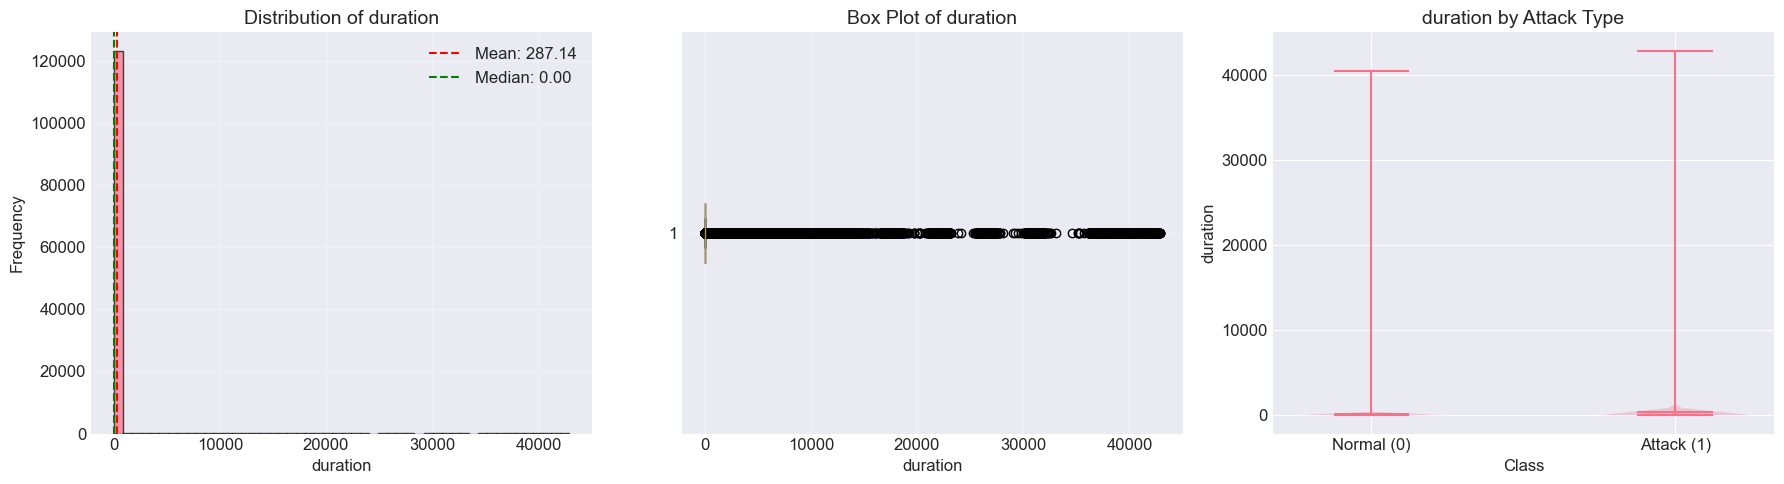

✅ Matplotlib chart saved: figures\Distribution_of_src_bytes.png (Size: 18.0x5.0 in, DPI: 300)


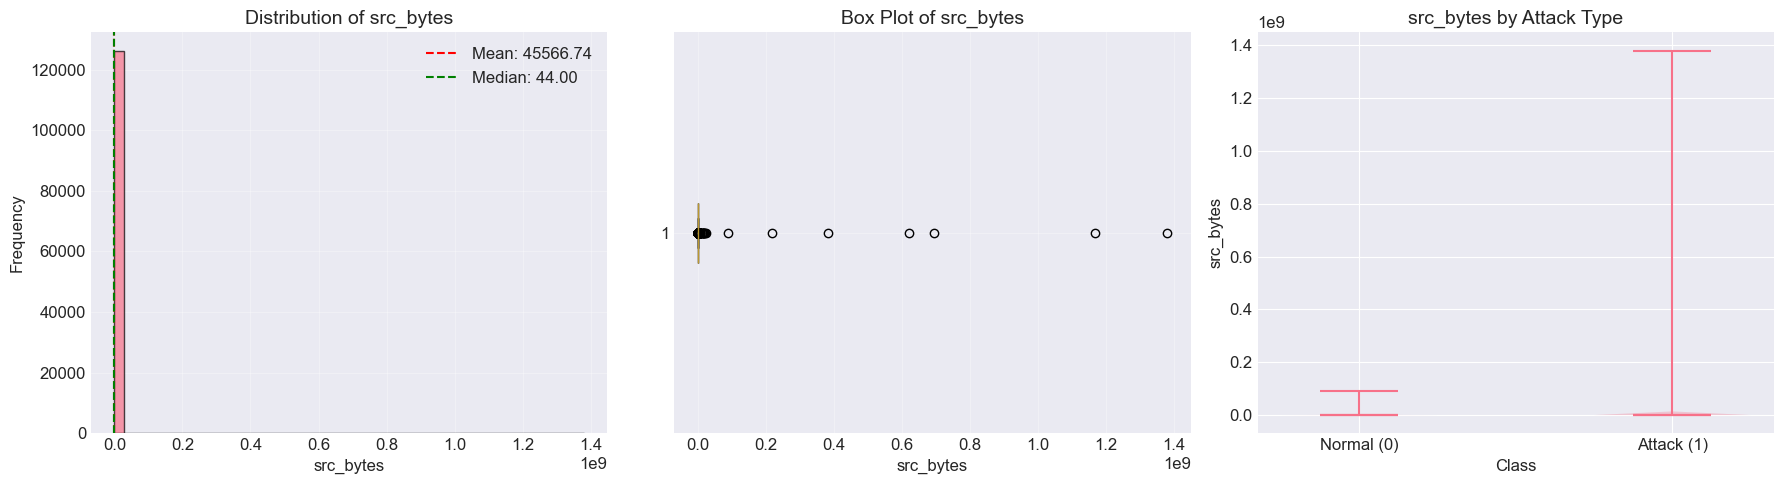

✅ Matplotlib chart saved: figures\Distribution_of_dst_bytes.png (Size: 18.0x5.0 in, DPI: 300)


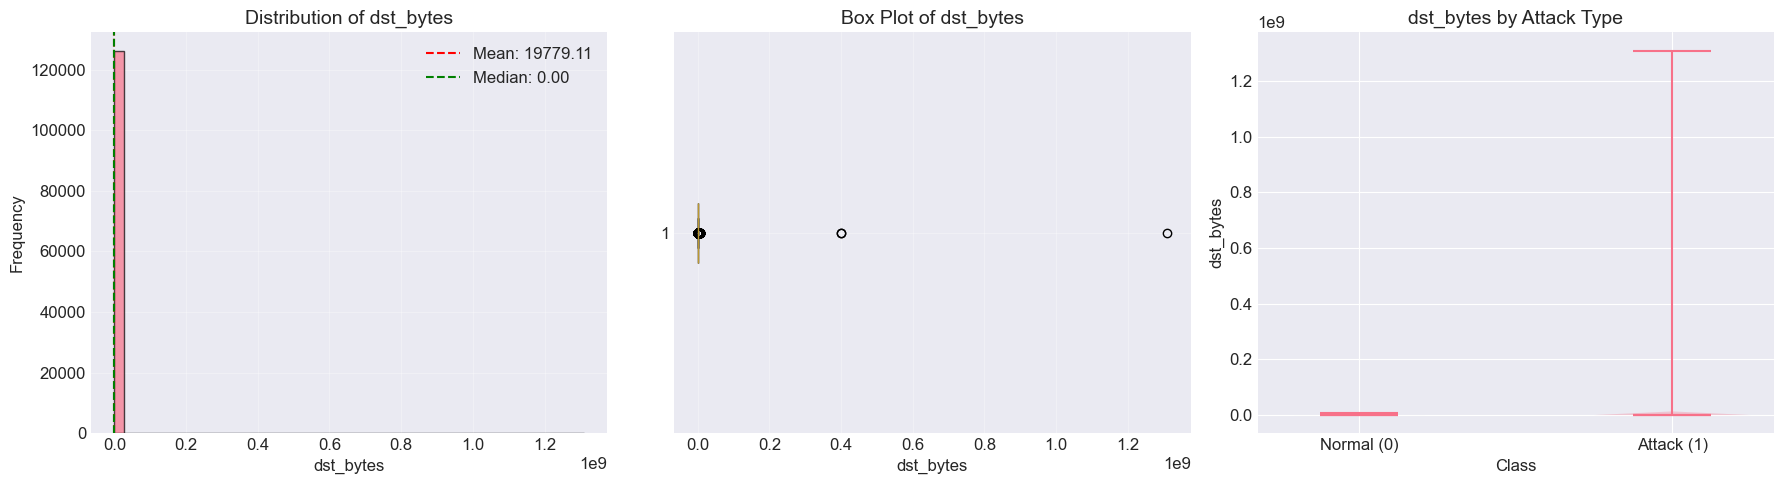

✅ Matplotlib chart saved: figures\Distribution_of_wrong_fragment.png (Size: 18.0x5.0 in, DPI: 300)


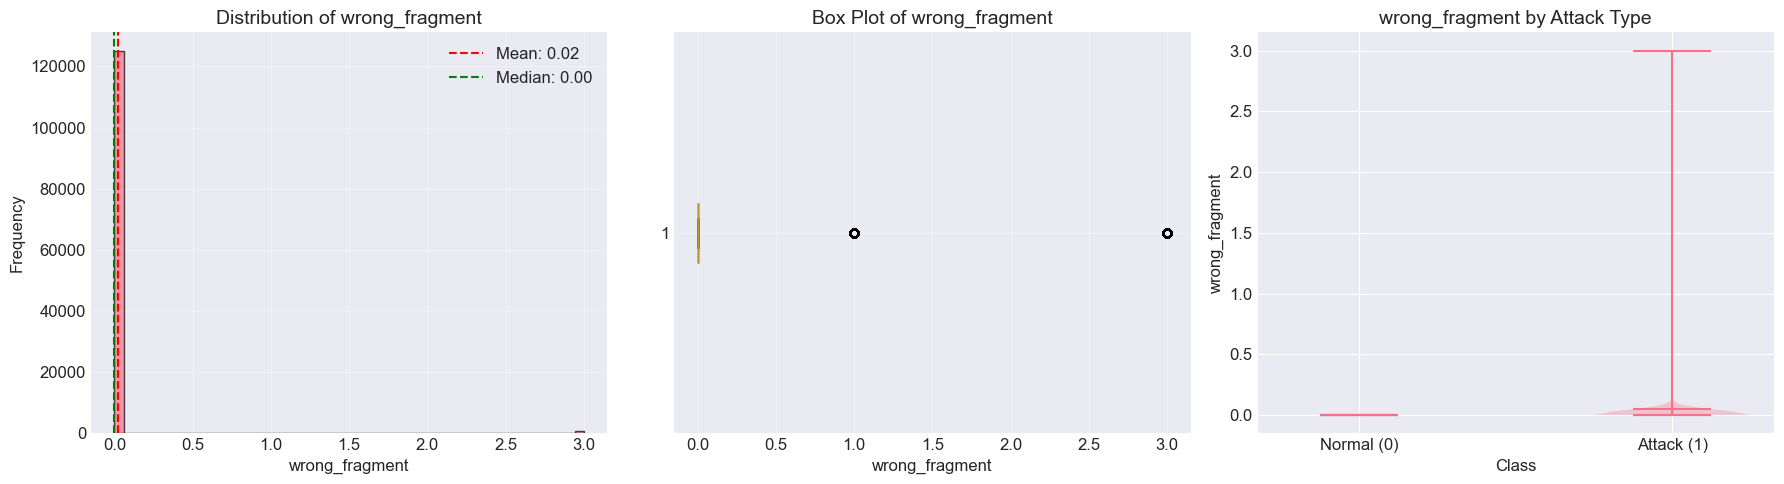

✅ Matplotlib chart saved: figures\Distribution_of_urgent.png (Size: 18.0x5.0 in, DPI: 300)


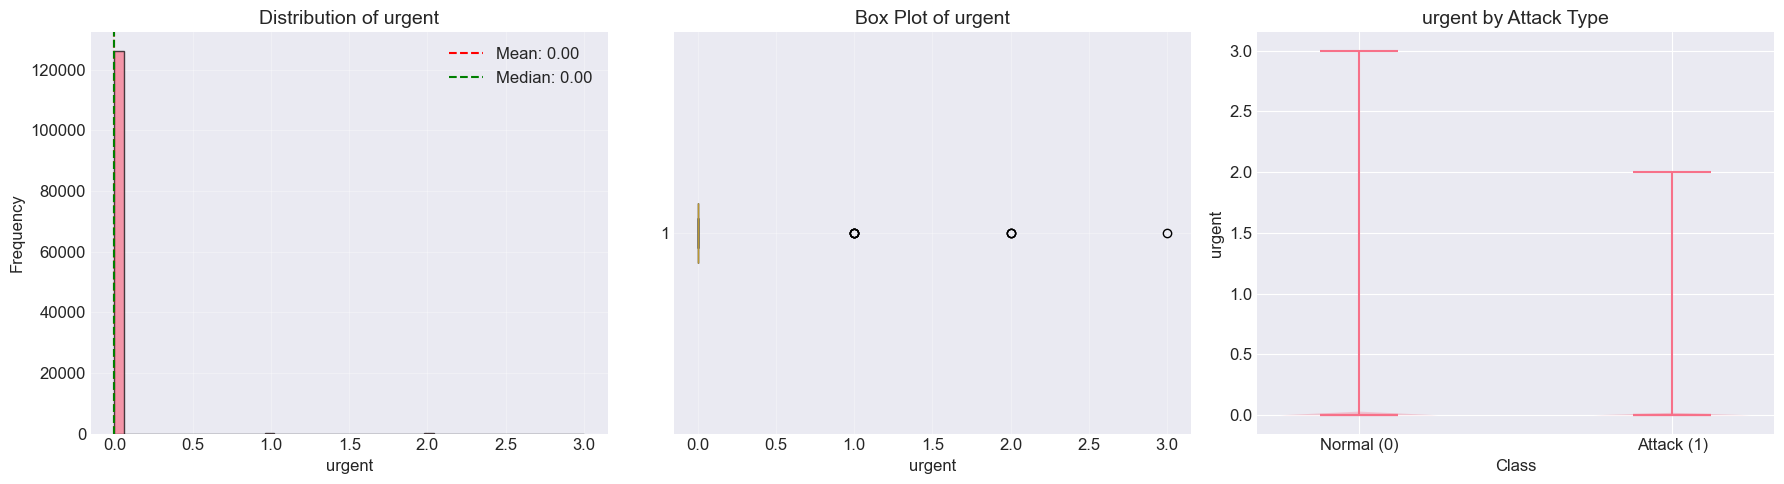

✅ Matplotlib chart saved: figures\Distribution_of_hot.png (Size: 18.0x5.0 in, DPI: 300)


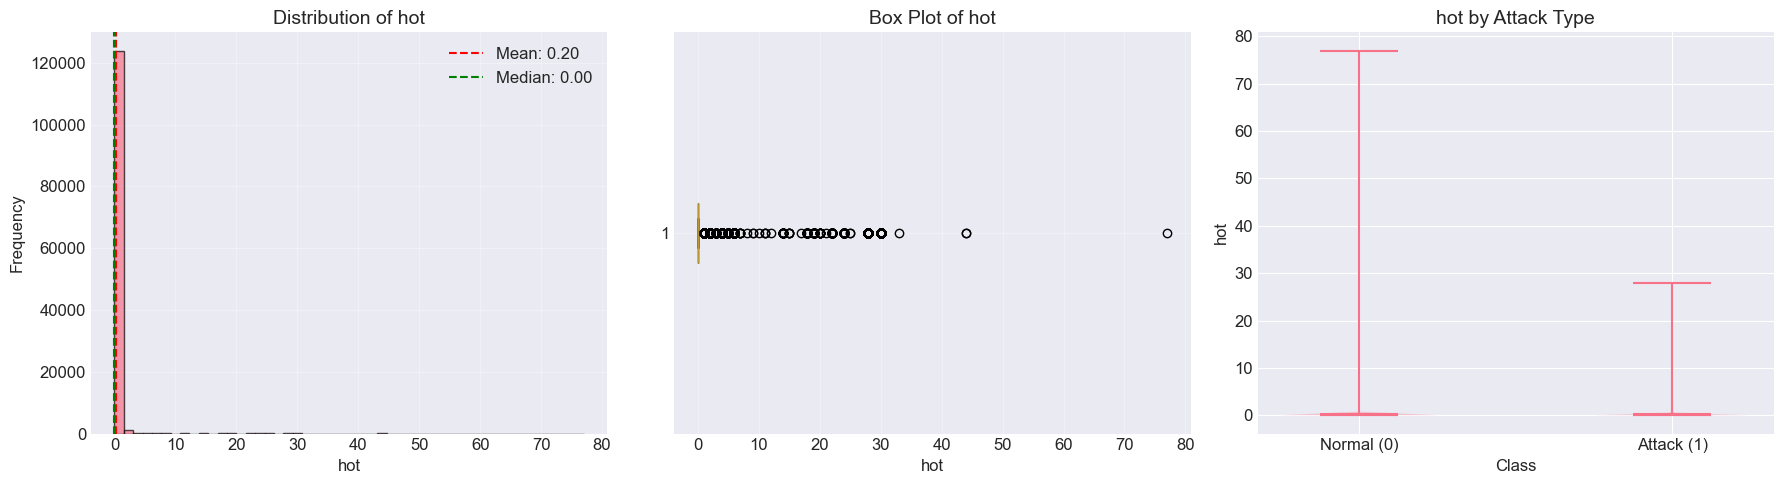

✅ Matplotlib chart saved: figures\Distribution_of_num_failed_logins.png (Size: 18.0x5.0 in, DPI: 300)


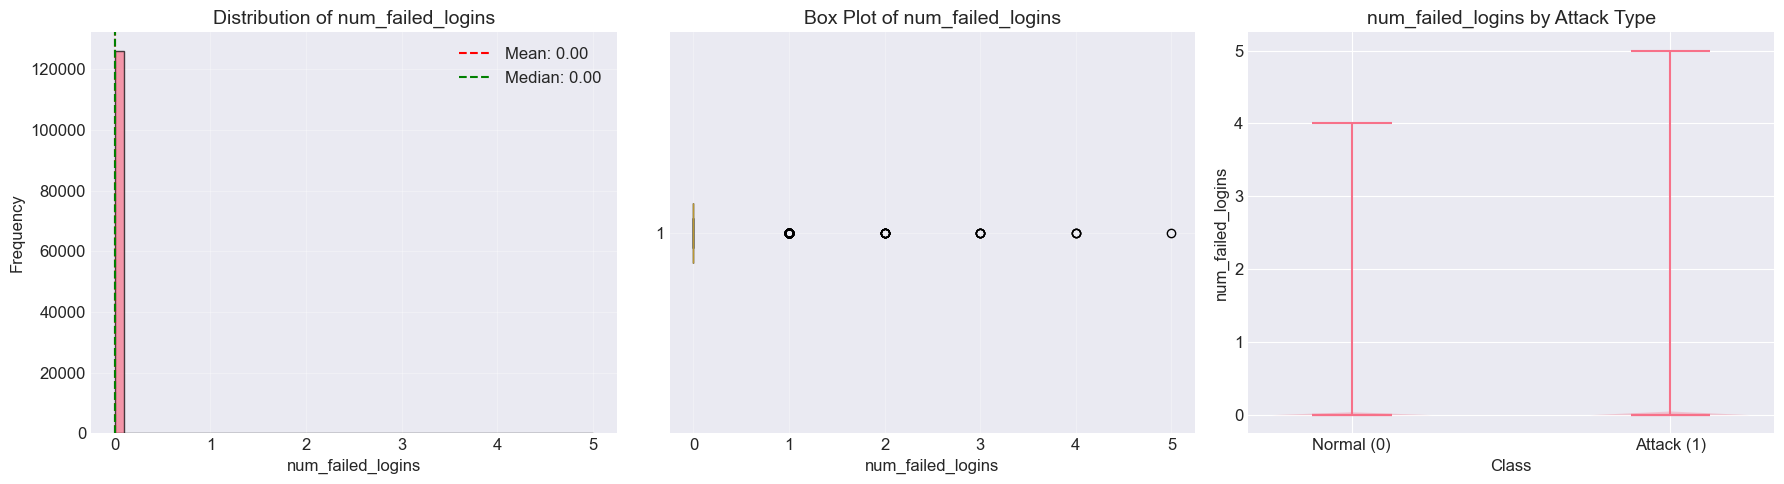

✅ Matplotlib chart saved: figures\Distribution_of_num_compromised.png (Size: 18.0x5.0 in, DPI: 300)


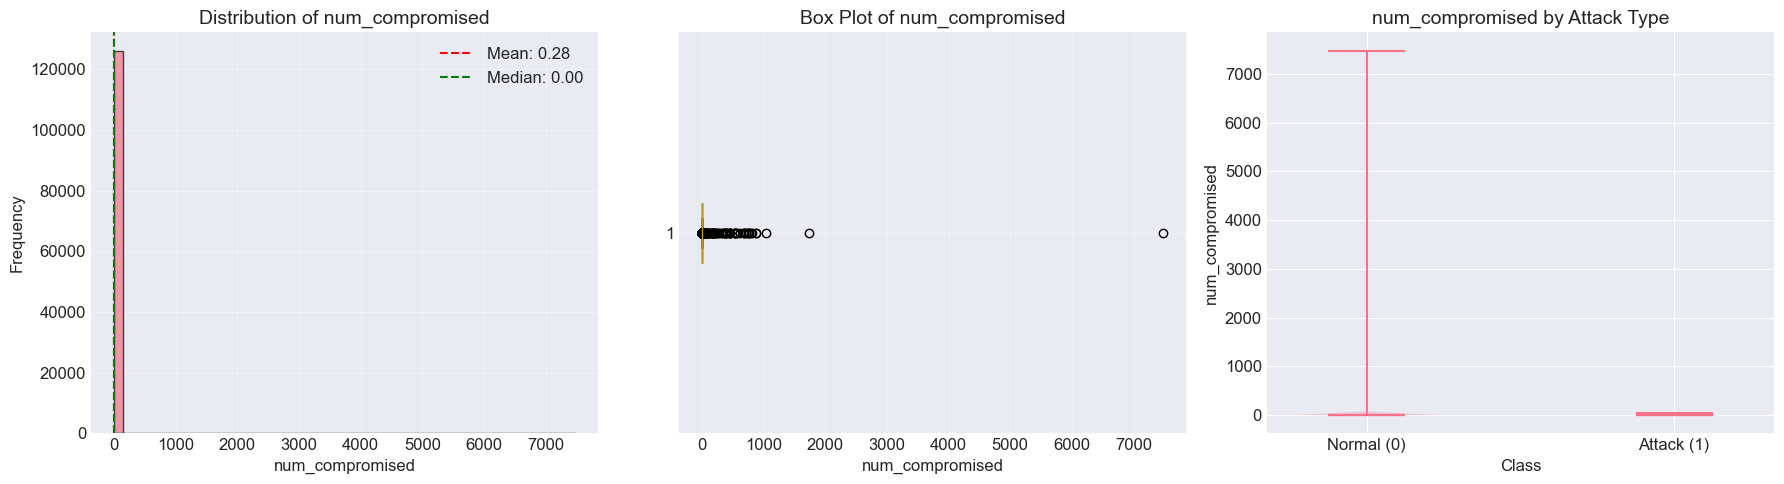

✅ Matplotlib chart saved: figures\Distribution_of_num_root.png (Size: 18.0x5.0 in, DPI: 300)


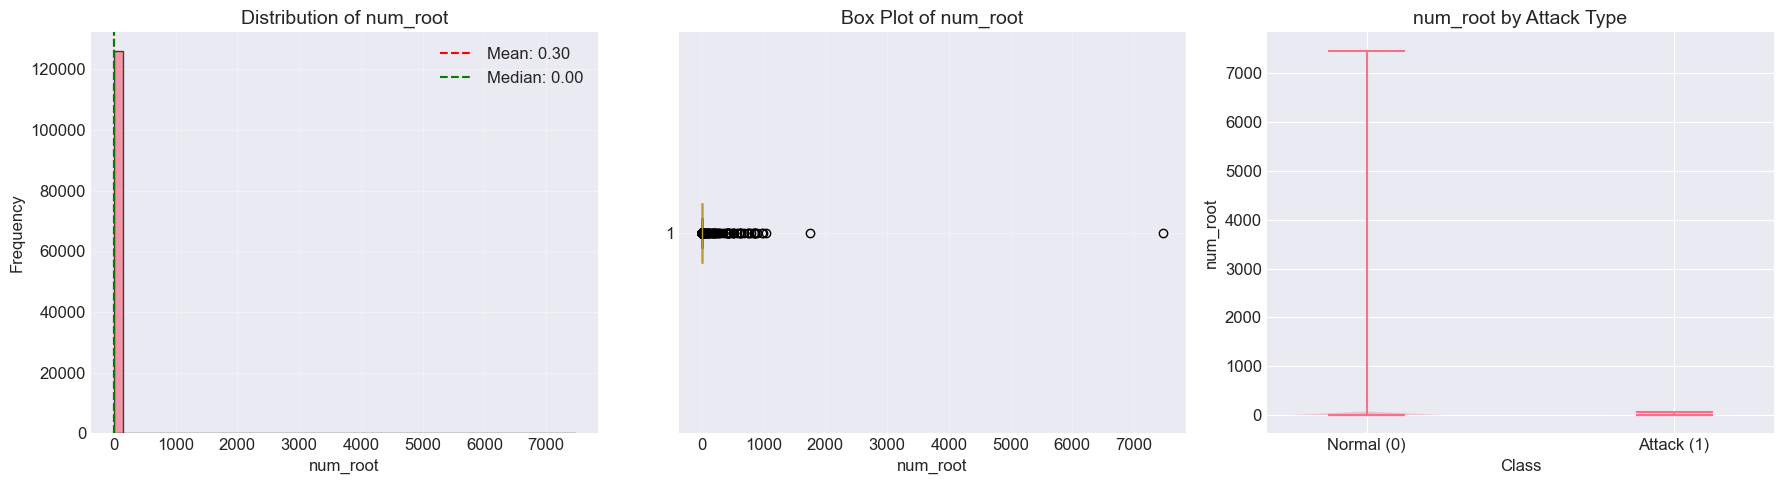

✅ Matplotlib chart saved: figures\Distribution_of_num_file_creations.png (Size: 18.0x5.0 in, DPI: 300)


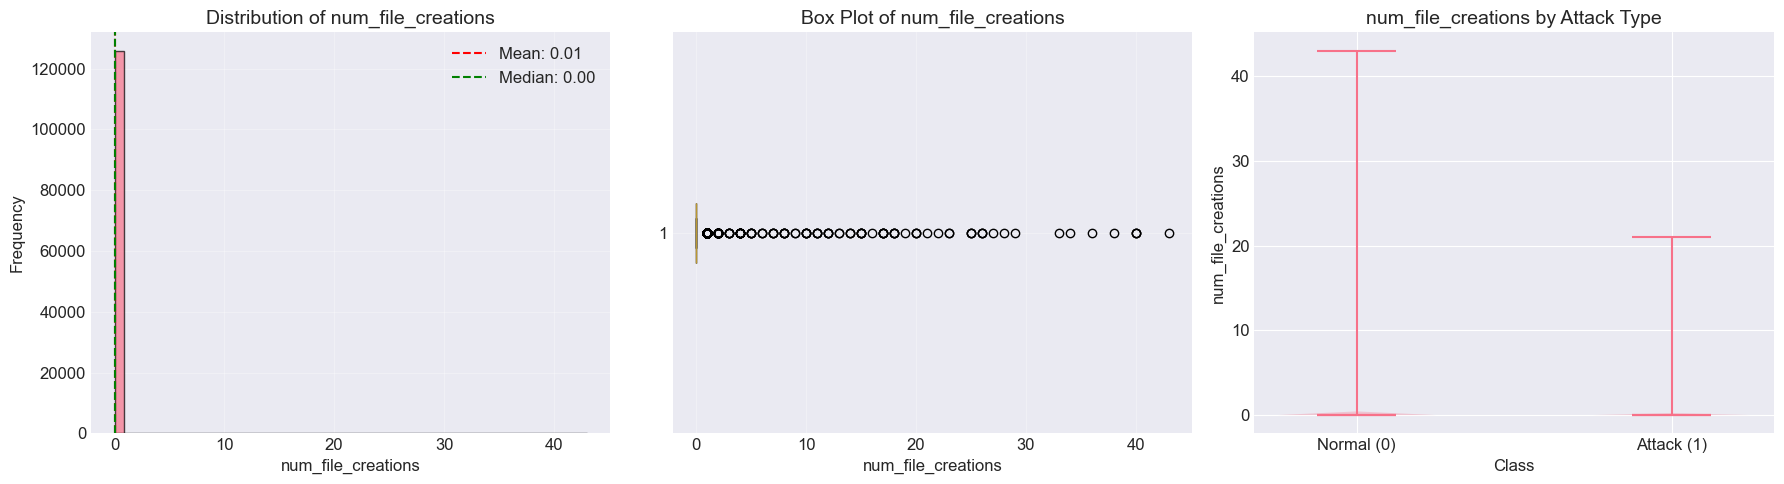

✅ Matplotlib chart saved: figures\Distribution_of_num_shells.png (Size: 18.0x5.0 in, DPI: 300)


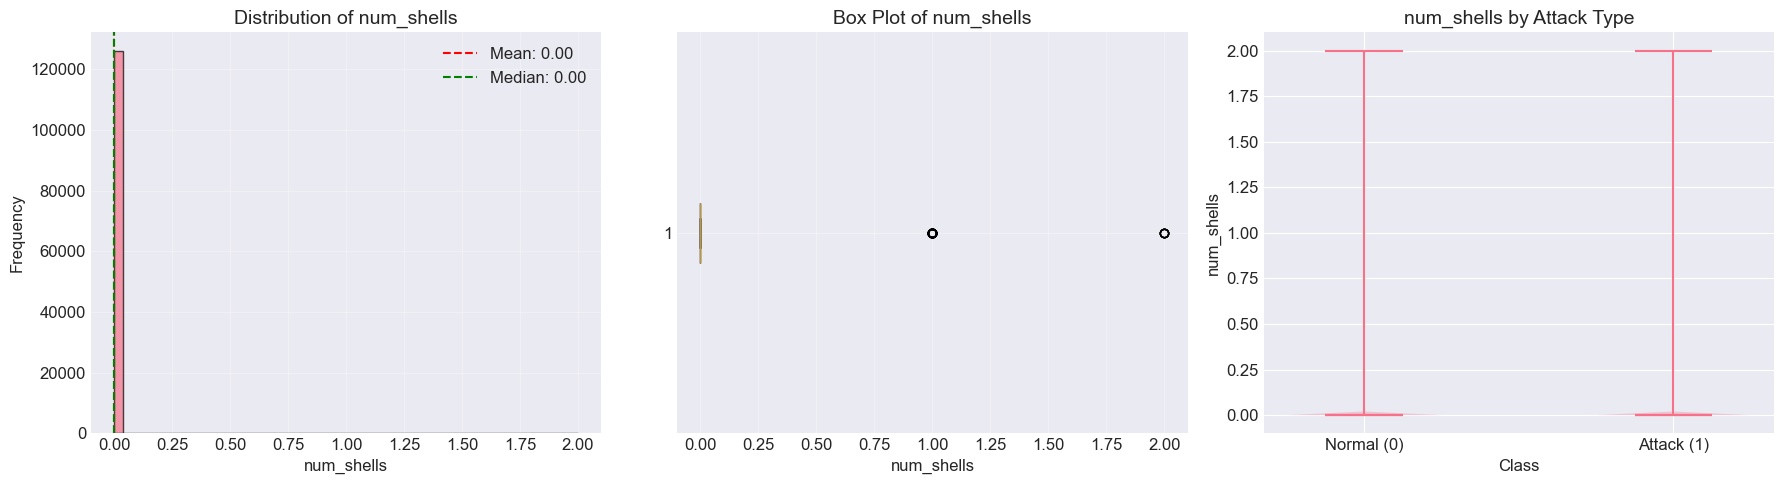

✅ Matplotlib chart saved: figures\Distribution_of_num_access_files.png (Size: 18.0x5.0 in, DPI: 300)


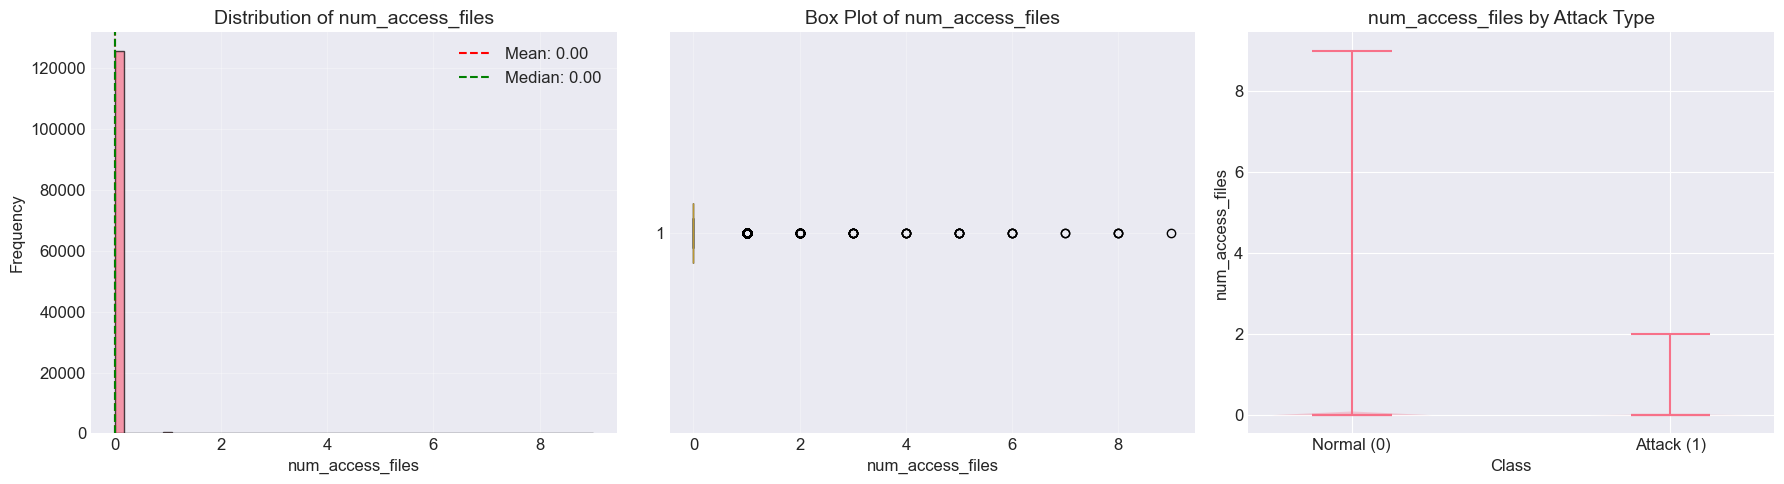

✅ Matplotlib chart saved: figures\Distribution_of_num_outbound_cmds.png (Size: 18.0x5.0 in, DPI: 300)


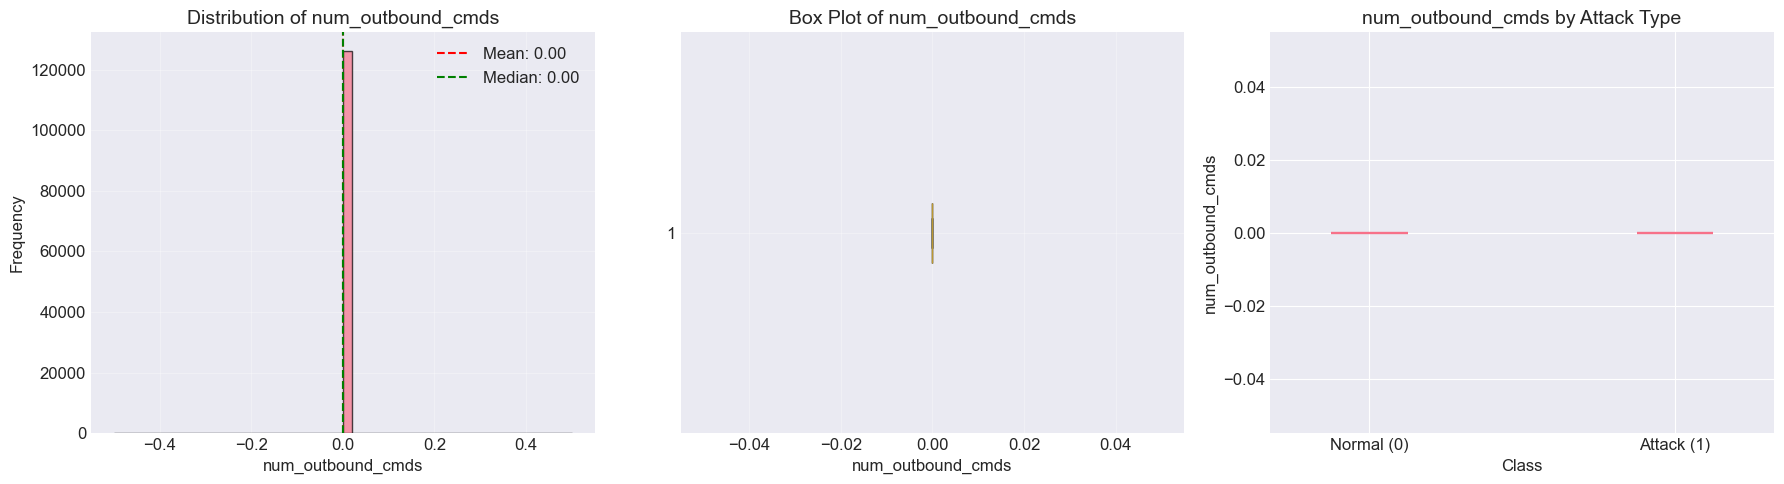

✅ Matplotlib chart saved: figures\Distribution_of_count.png (Size: 18.0x5.0 in, DPI: 300)


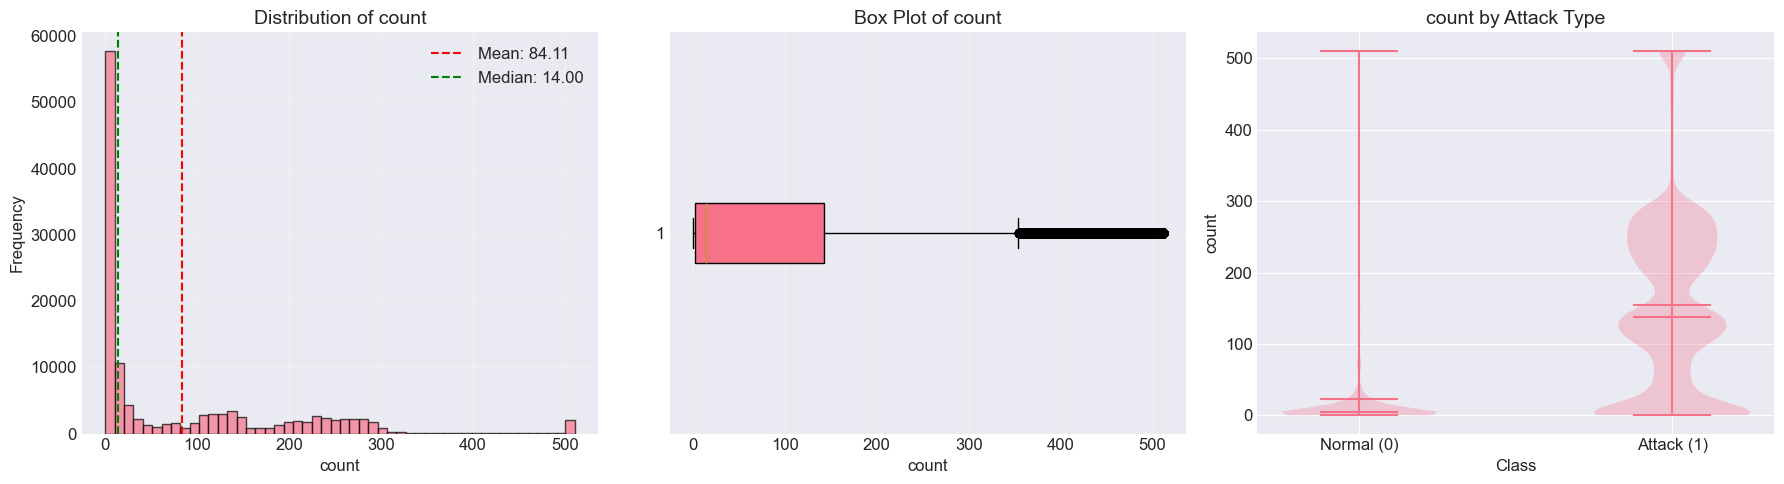

✅ Matplotlib chart saved: figures\Distribution_of_srv_count.png (Size: 18.0x5.0 in, DPI: 300)


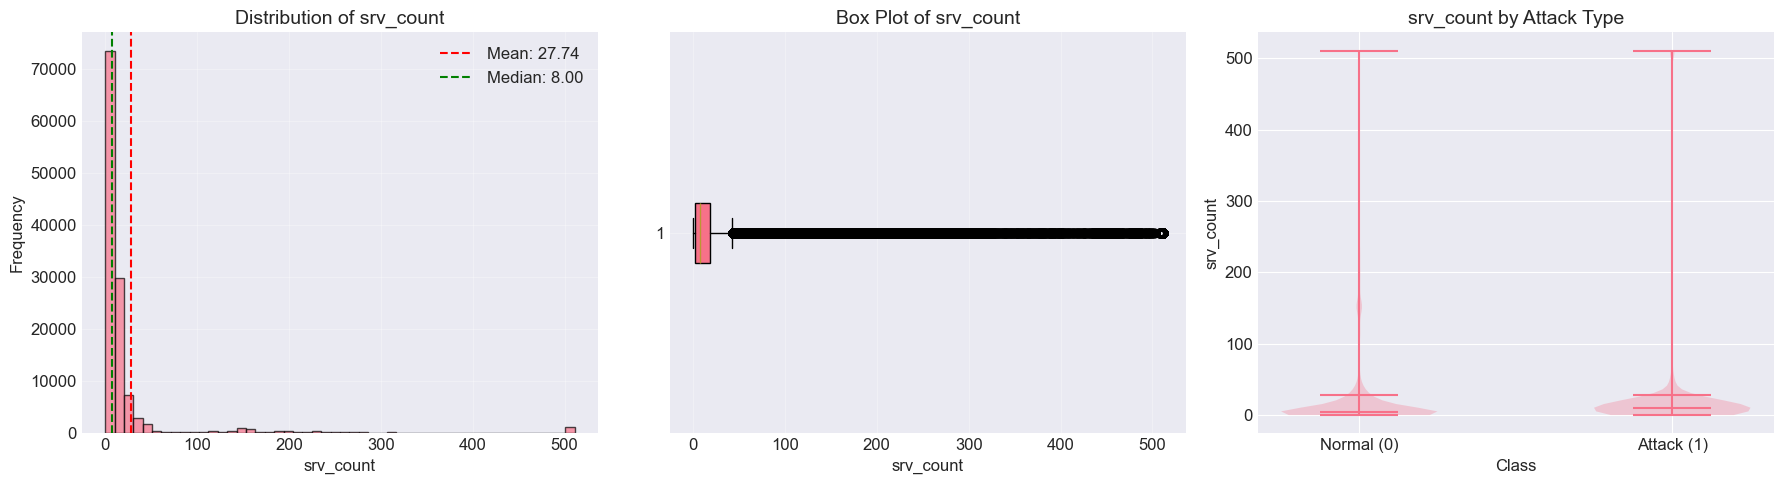

✅ Matplotlib chart saved: figures\Distribution_of_dst_host_count.png (Size: 18.0x5.0 in, DPI: 300)


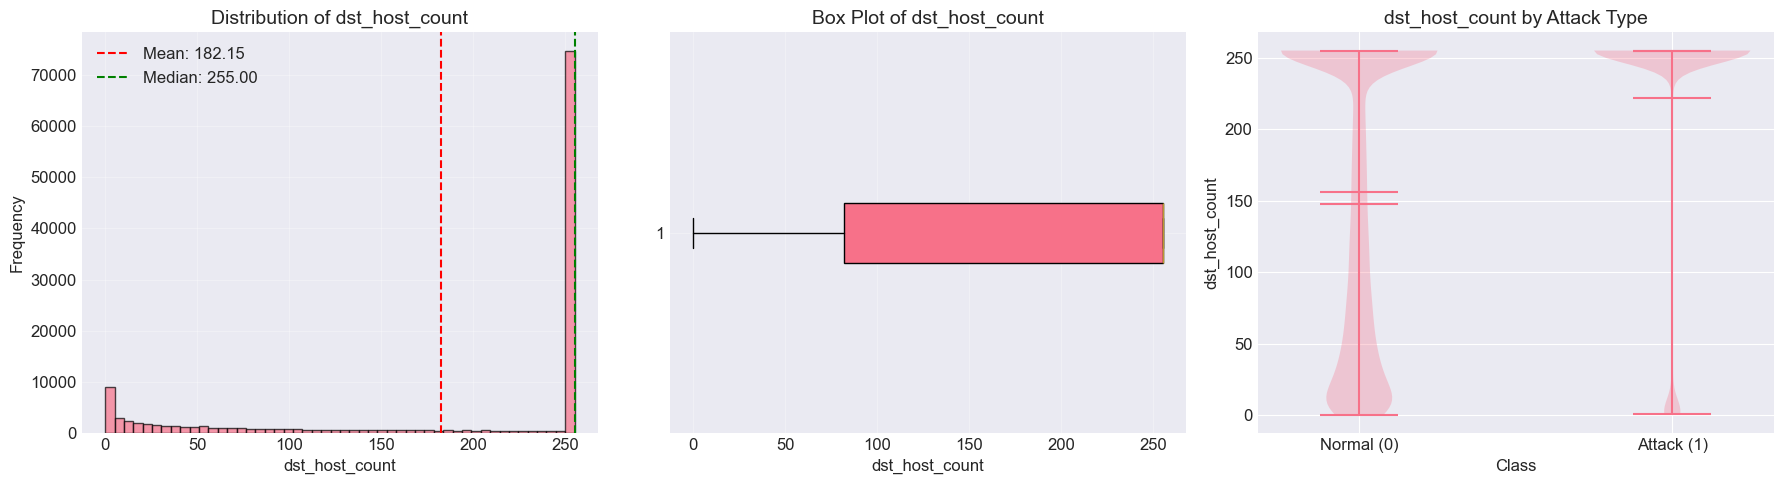

✅ Matplotlib chart saved: figures\Distribution_of_dst_host_srv_count.png (Size: 18.0x5.0 in, DPI: 300)


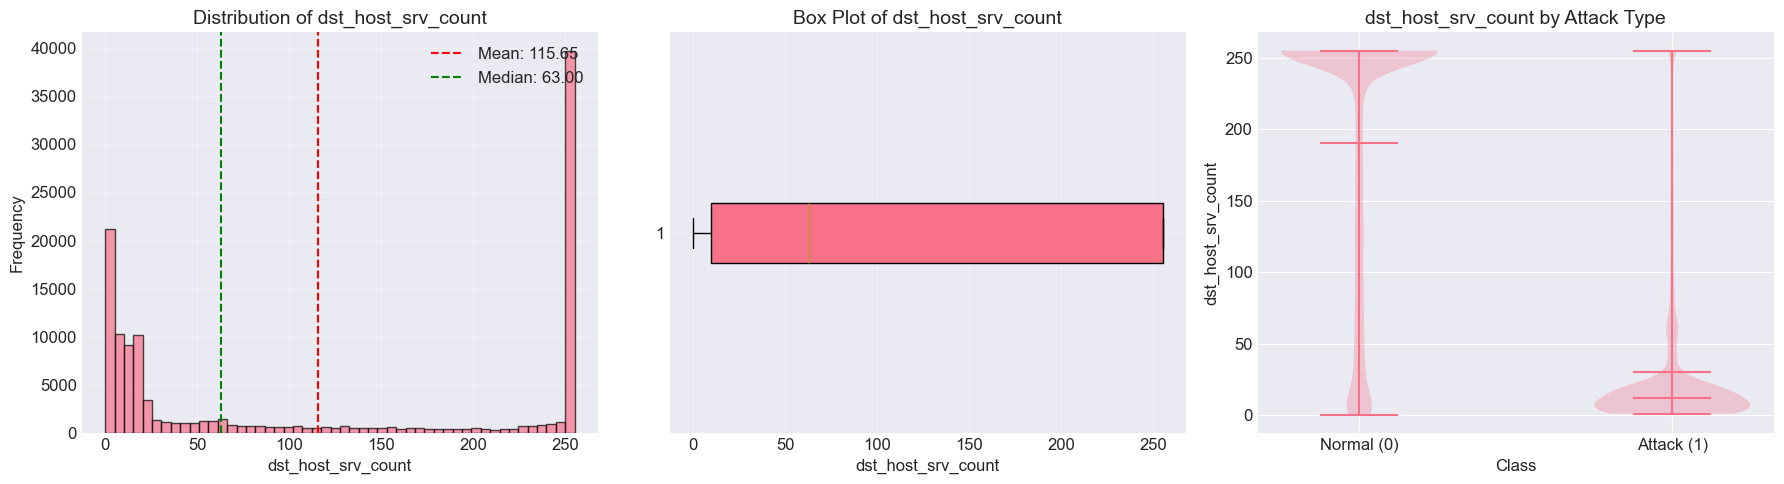

✅ Matplotlib chart saved: figures\Distribution_of_serror_rate.png (Size: 18.0x5.0 in, DPI: 300)


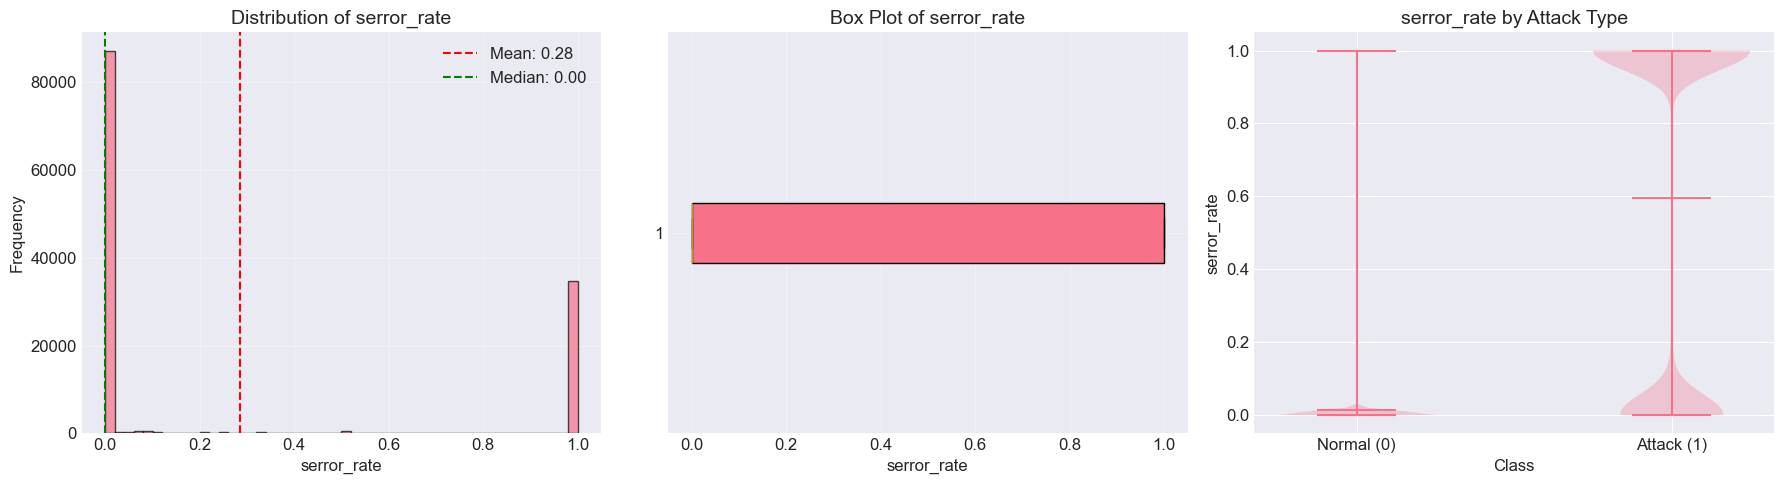

✅ Matplotlib chart saved: figures\Distribution_of_srv_serror_rate.png (Size: 18.0x5.0 in, DPI: 300)


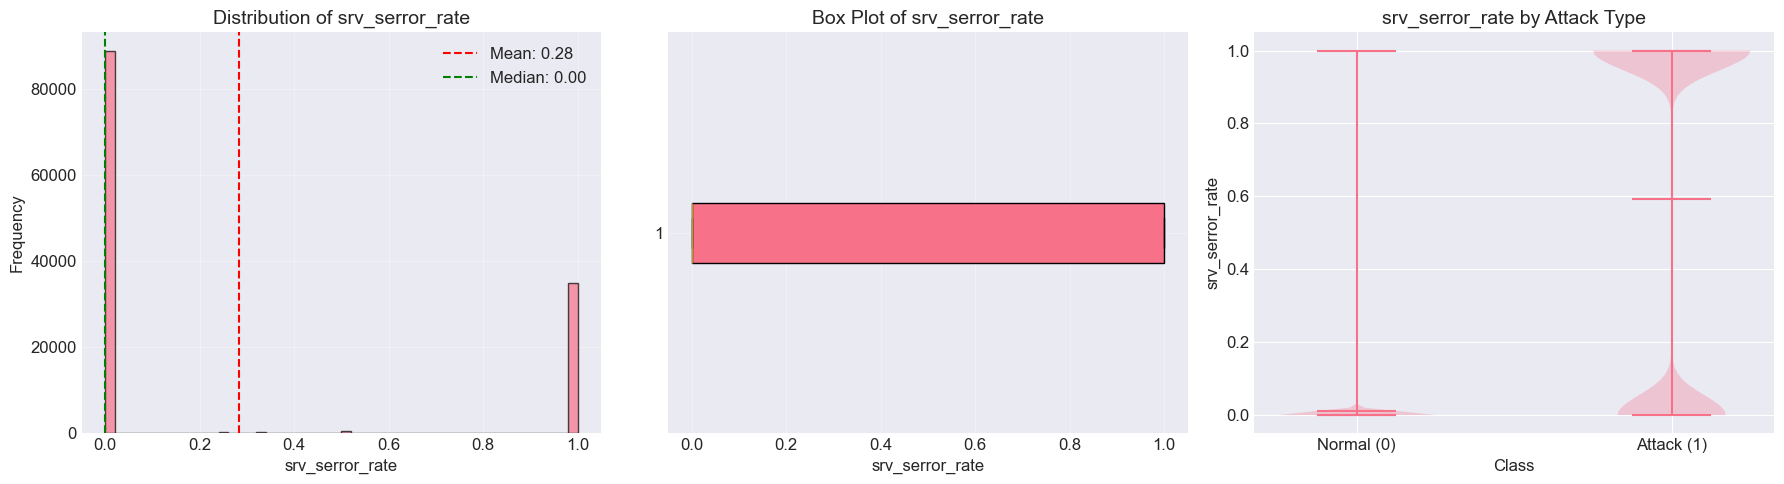

✅ Matplotlib chart saved: figures\Distribution_of_rerror_rate.png (Size: 18.0x5.0 in, DPI: 300)


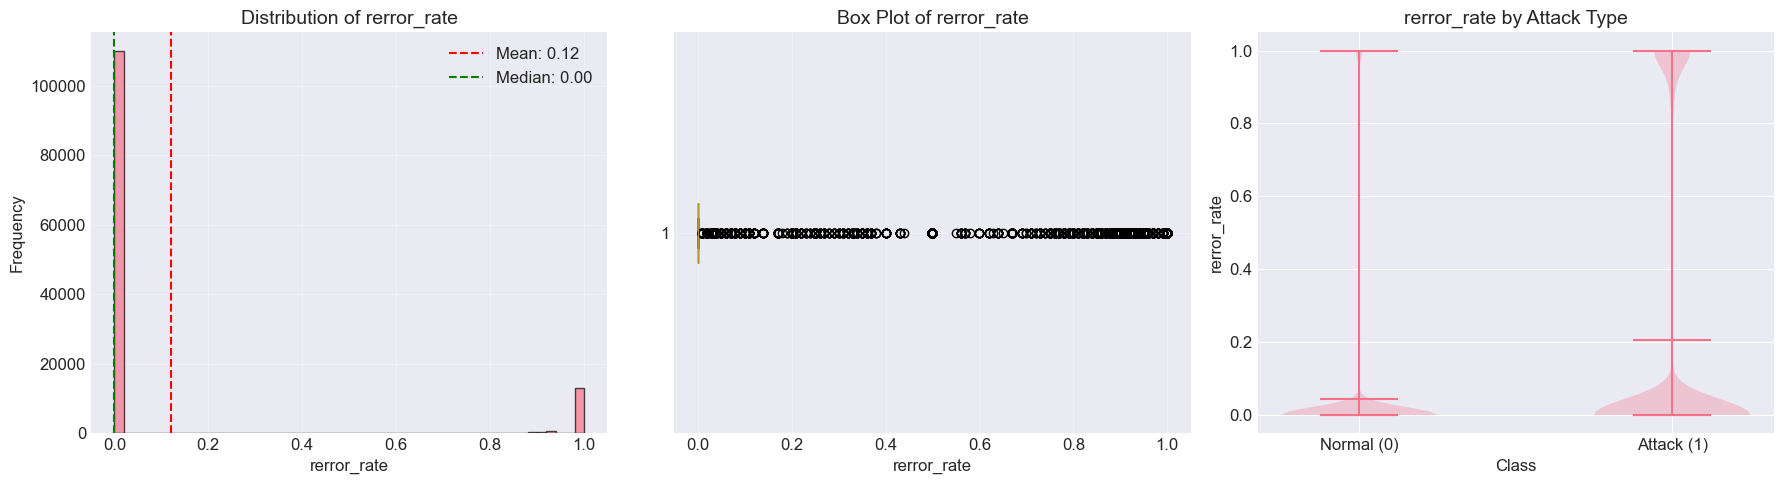

✅ Matplotlib chart saved: figures\Distribution_of_srv_rerror_rate.png (Size: 18.0x5.0 in, DPI: 300)


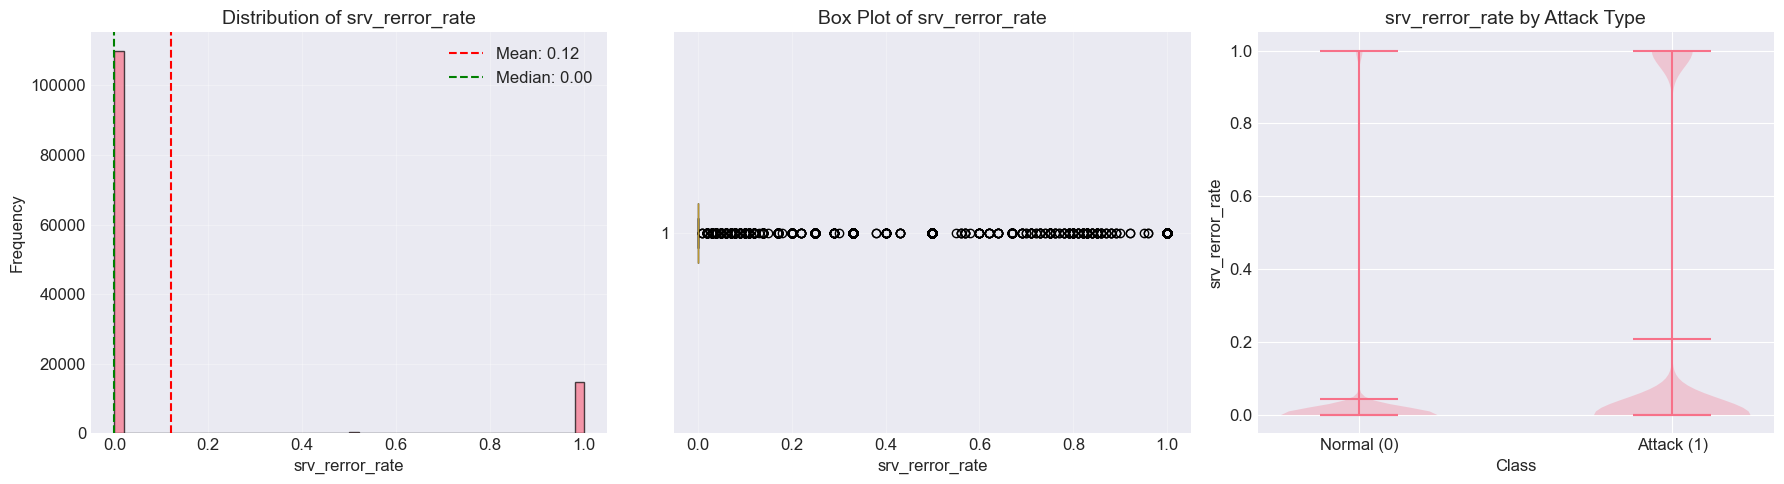

✅ Matplotlib chart saved: figures\Distribution_of_same_srv_rate.png (Size: 18.0x5.0 in, DPI: 300)


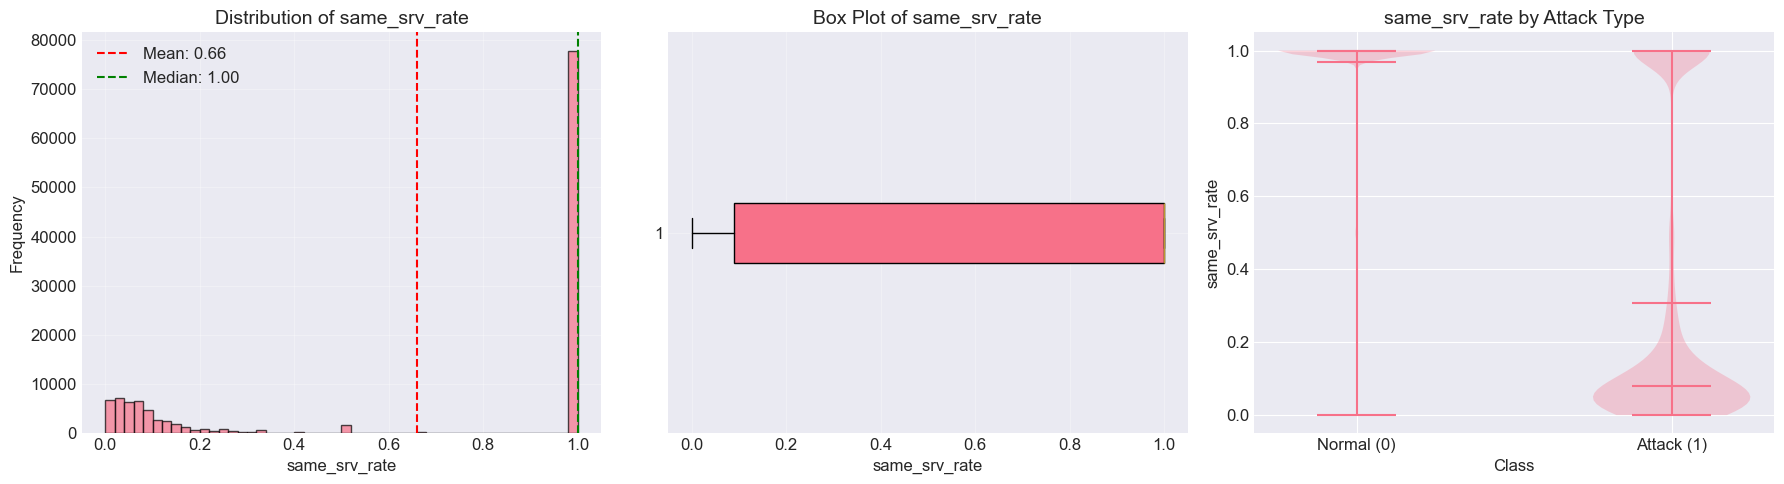

✅ Matplotlib chart saved: figures\Distribution_of_diff_srv_rate.png (Size: 18.0x5.0 in, DPI: 300)


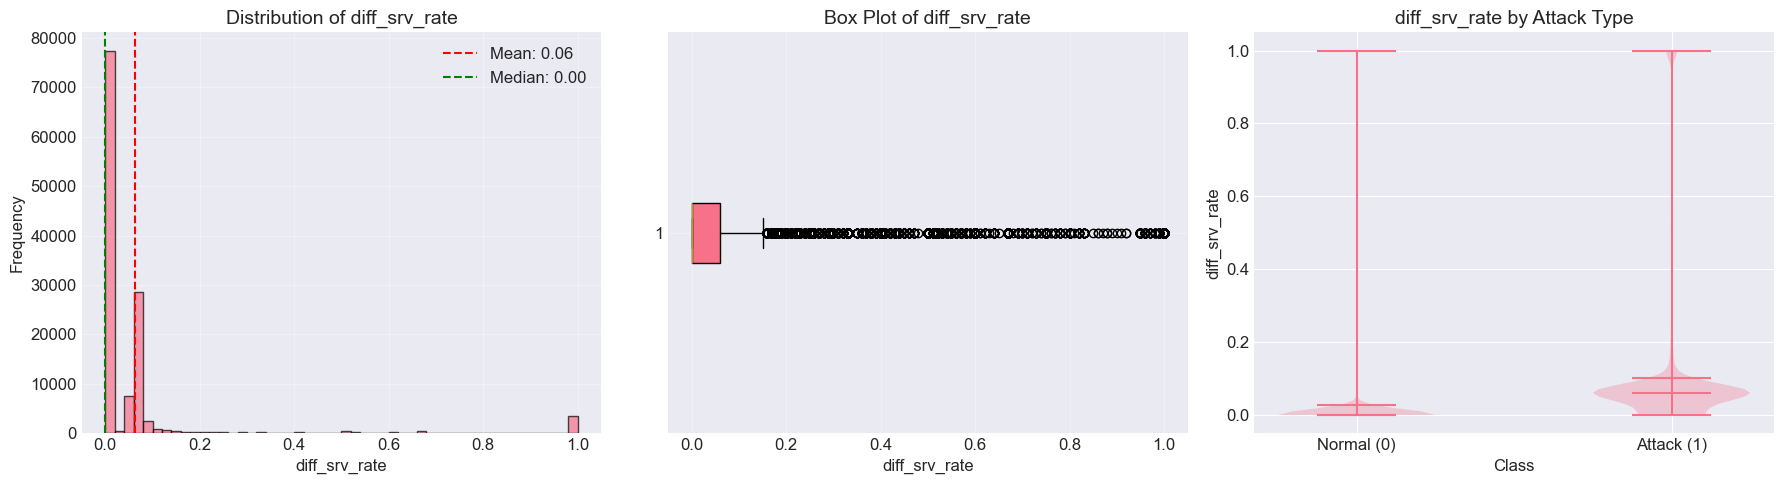

✅ Matplotlib chart saved: figures\Distribution_of_srv_diff_host_rate.png (Size: 18.0x5.0 in, DPI: 300)


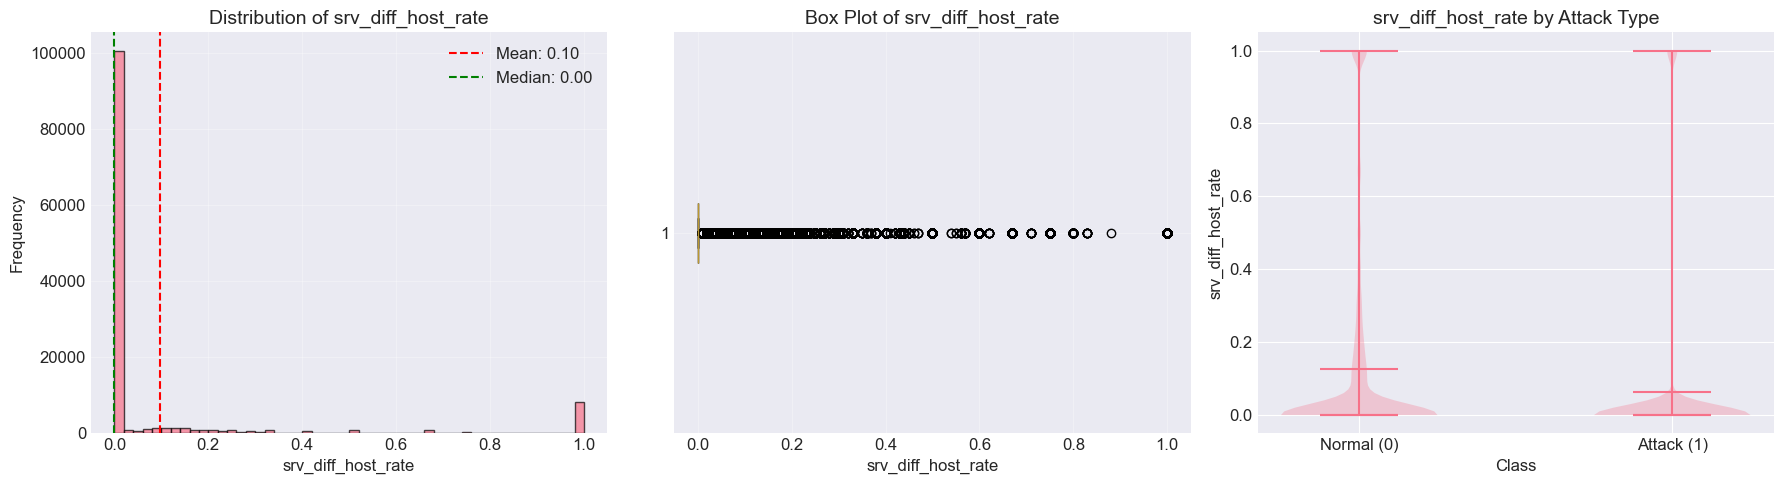

✅ Matplotlib chart saved: figures\Distribution_of_dst_host_same_srv_rate.png (Size: 18.0x5.0 in, DPI: 300)


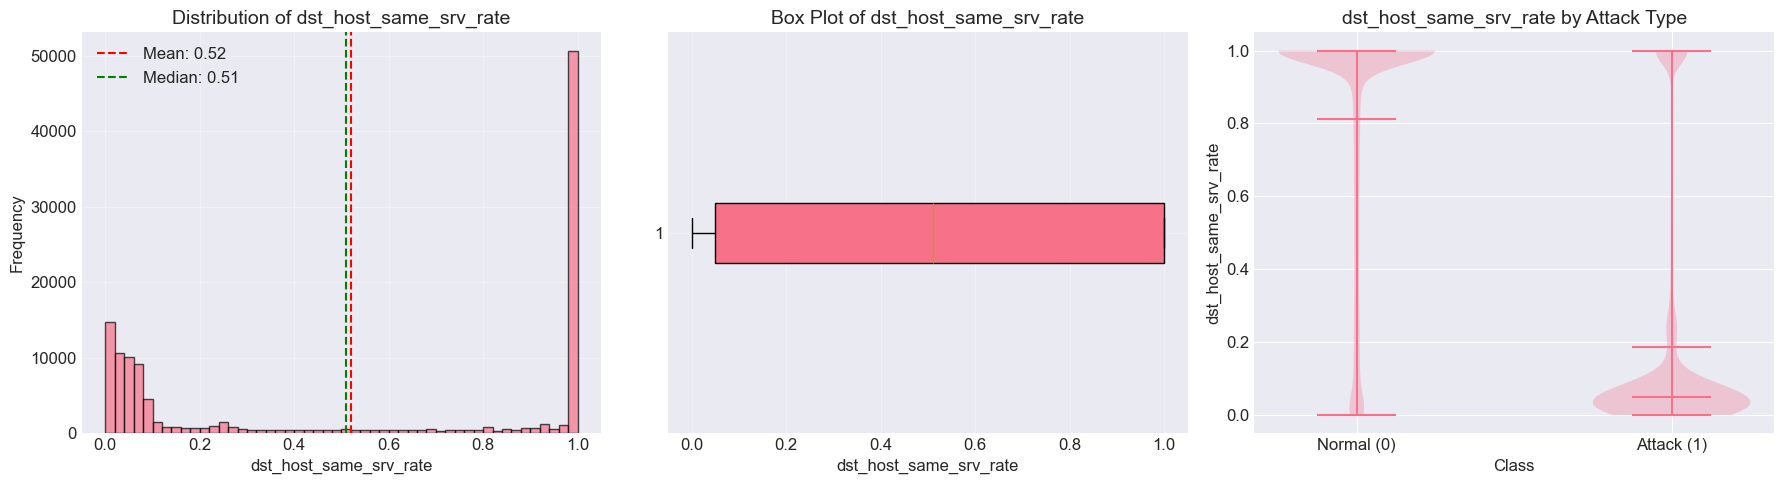

✅ Matplotlib chart saved: figures\Distribution_of_dst_host_diff_srv_rate.png (Size: 18.0x5.0 in, DPI: 300)


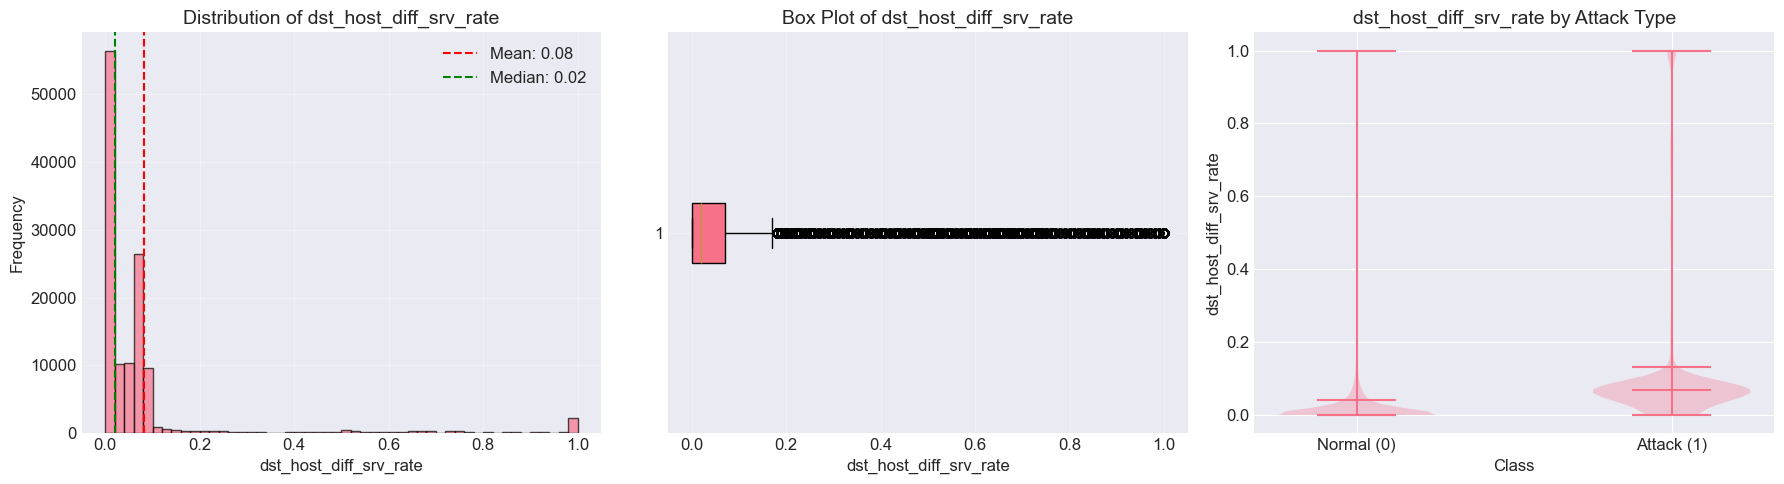

✅ Matplotlib chart saved: figures\Distribution_of_dst_host_same_src_port_rate.png (Size: 18.0x5.0 in, DPI: 300)


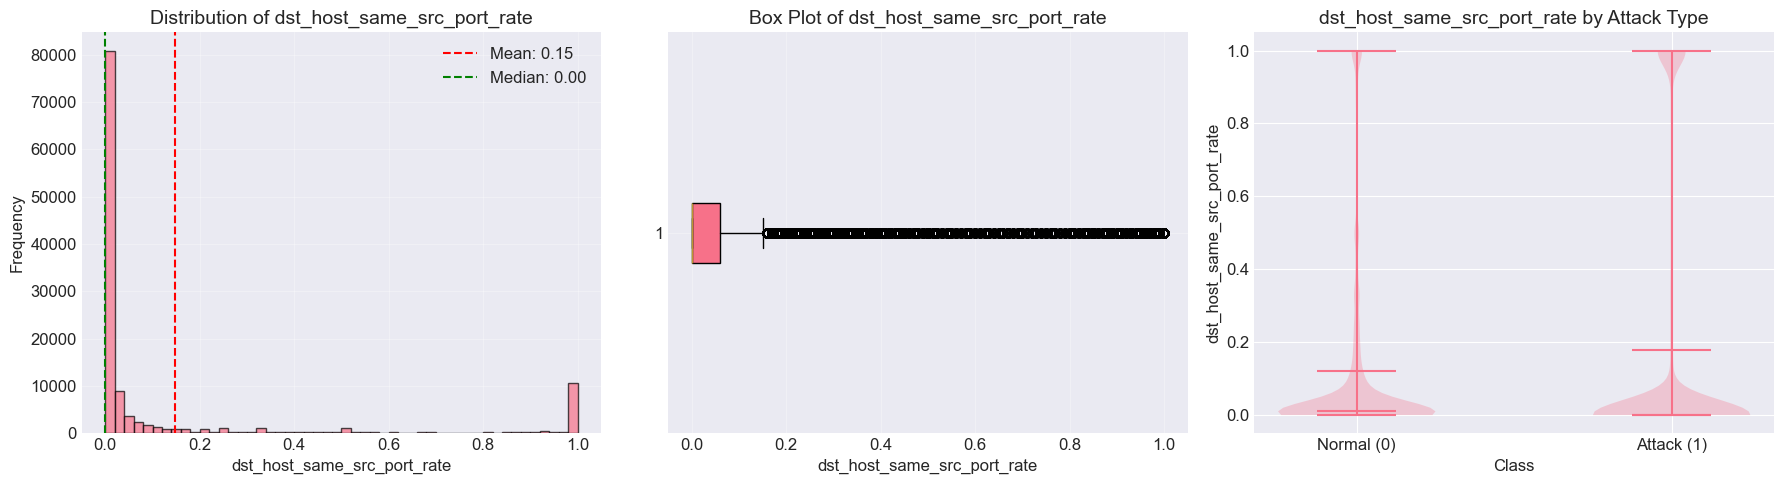

✅ Matplotlib chart saved: figures\Distribution_of_dst_host_srv_diff_host_rate.png (Size: 18.0x5.0 in, DPI: 300)


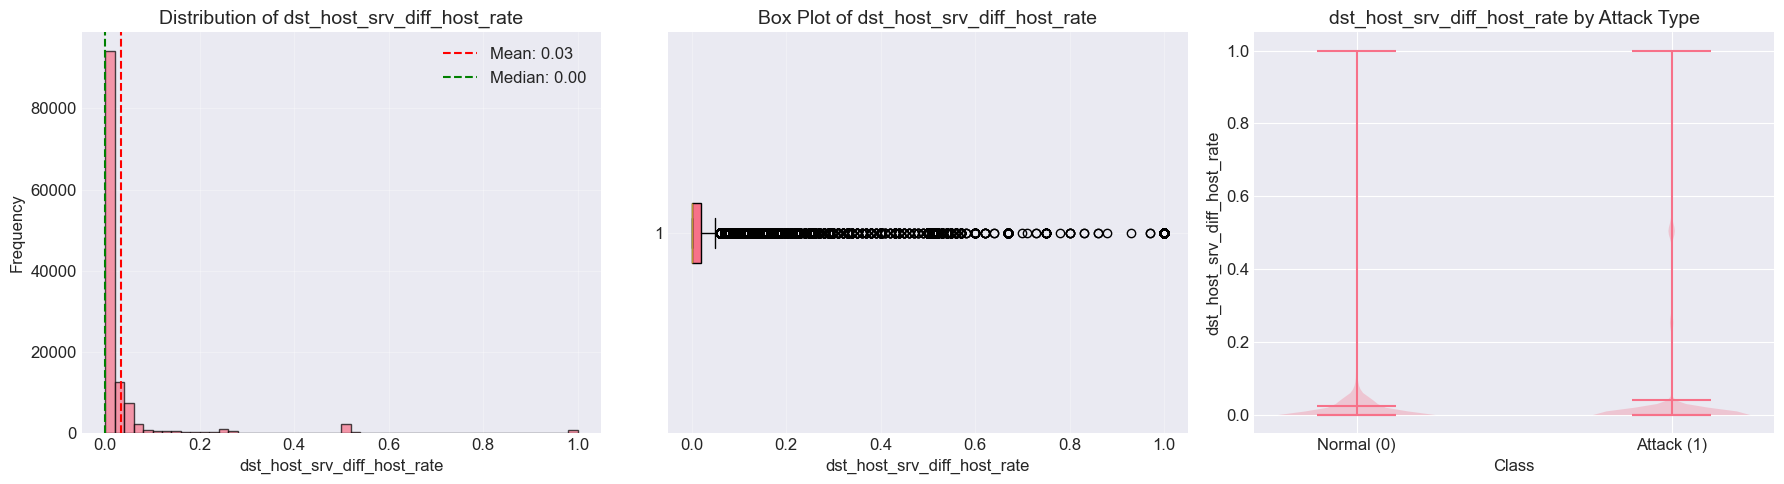

✅ Matplotlib chart saved: figures\Distribution_of_dst_host_serror_rate.png (Size: 18.0x5.0 in, DPI: 300)


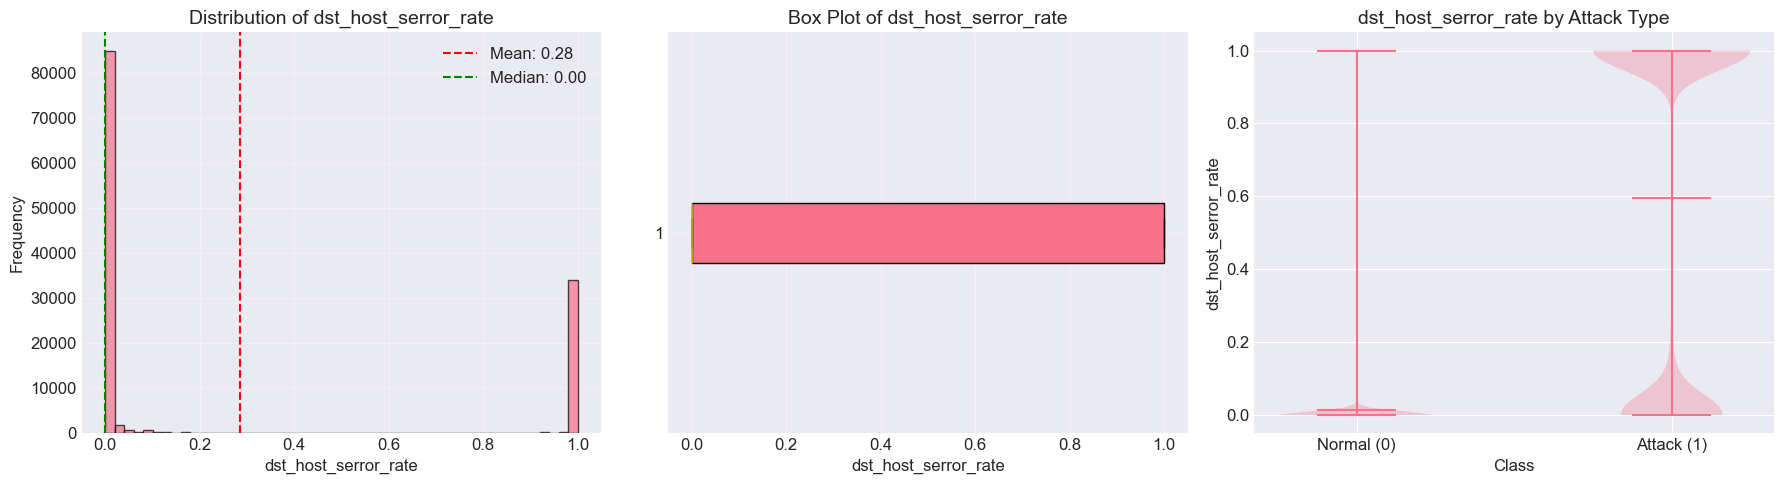

✅ Matplotlib chart saved: figures\Distribution_of_dst_host_srv_serror_rate.png (Size: 18.0x5.0 in, DPI: 300)


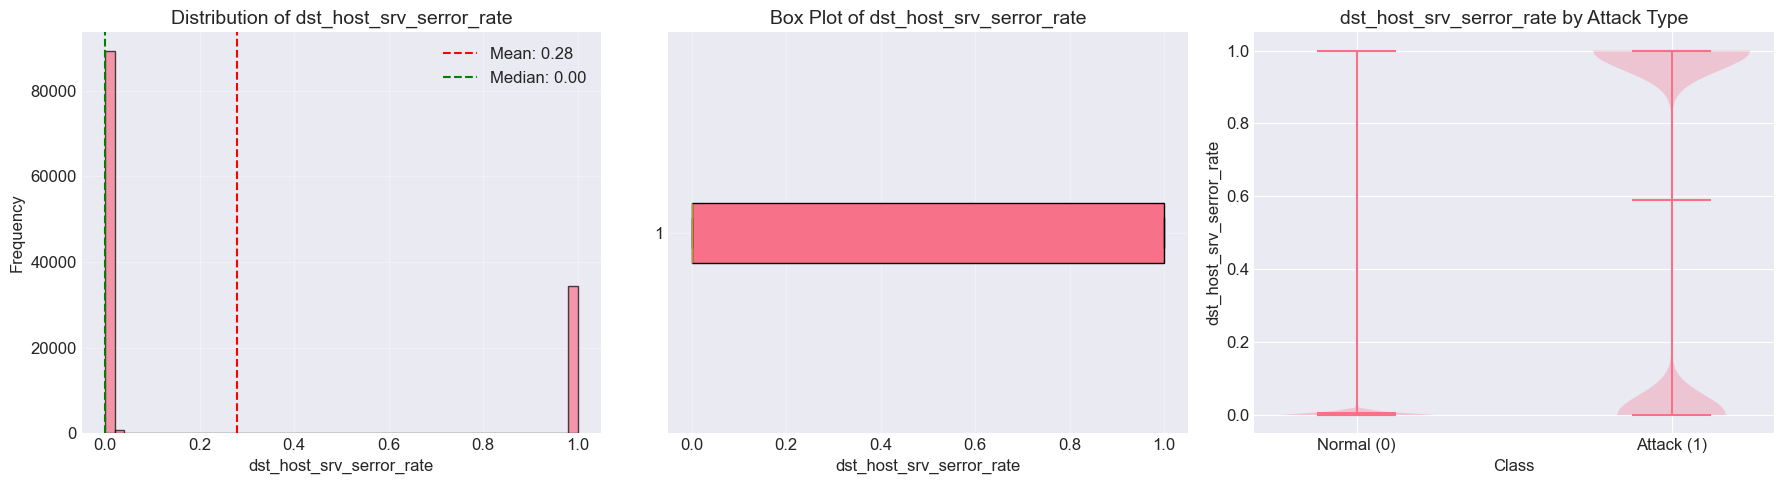

✅ Matplotlib chart saved: figures\Distribution_of_dst_host_rerror_rate.png (Size: 18.0x5.0 in, DPI: 300)


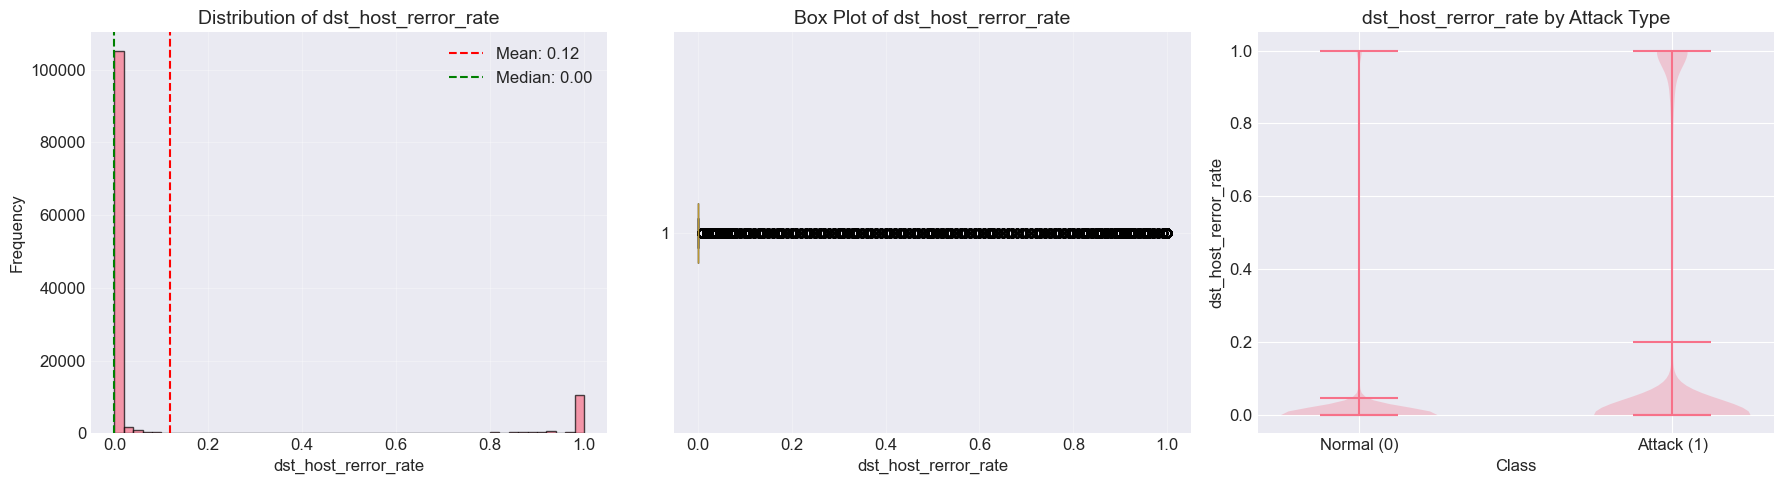

✅ Matplotlib chart saved: figures\Distribution_of_dst_host_srv_rerror_rate.png (Size: 18.0x5.0 in, DPI: 300)


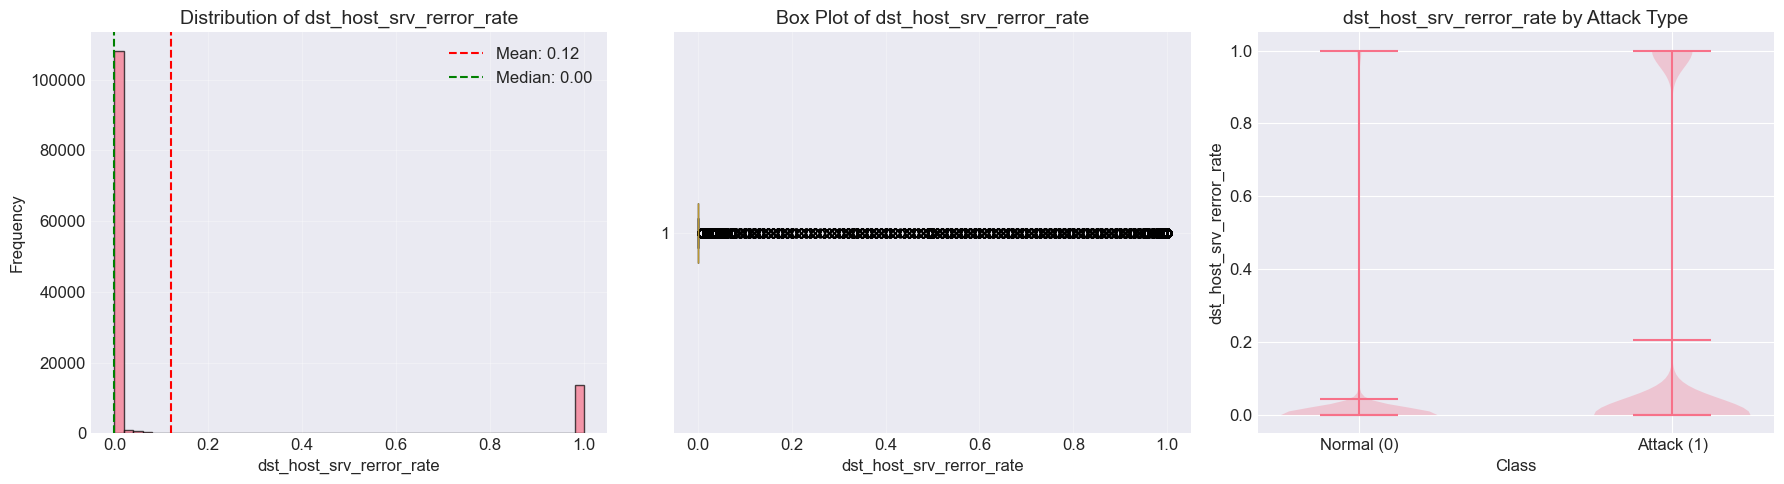

In [26]:
# Combine numerical + rate features
for col in num_cols + rate_cols:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # -------------------------
    # 1. Histogram
    # -------------------------
    data = train_df[col].dropna()

    axes[0].hist(data, bins=50, alpha=0.7, edgecolor="black")
    axes[0].axvline(data.mean(), color="red", linestyle="--", 
                    label=f"Mean: {data.mean():.2f}")
    axes[0].axvline(data.median(), color="green", linestyle="--", 
                    label=f"Median: {data.median():.2f}")

    axes[0].set_title(f"Distribution of {col}", fontsize=14)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # -------------------------
    # 2. Box Plot
    # -------------------------
    axes[1].boxplot(data, vert=False, patch_artist=True)
    axes[1].set_title(f"Box Plot of {col}", fontsize=14)
    axes[1].set_xlabel(col)
    axes[1].grid(alpha=0.3)

    # -------------------------
    # 3. Violin Plot (Binary Target)
    # -------------------------
    binary_sample = train_df[['is_attack_binary', col]].dropna()

    normal_data = binary_sample[binary_sample['is_attack_binary'] == 0][col].values
    attack_data = binary_sample[binary_sample['is_attack_binary'] == 1][col].values

    axes[2].violinplot(
        [normal_data, attack_data],
        showmeans=True,
        showmedians=True
    )

    axes[2].set_title(f"{col} by Attack Type", fontsize=14)
    axes[2].set_xlabel("Class")
    axes[2].set_ylabel(col)
    axes[2].set_xticks([1, 2])
    axes[2].set_xticklabels(["Normal (0)", "Attack (1)"])
    plt.tight_layout()
    save_chart(show=False)
    plt.show()

| #  | Feature (chart title)                        | What the histogram shows                                                                                          | What the boxplot tells you                                                                                                 | Interpretation / Key observation for your report                                                                                                                                                                                                                                                                                                                              |
|----|---------------------------------------------|-------------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| 1  | num_access_files                            | Extremely sharp peak at 0, almost all sessions have 0 access_files, very tiny tail up to ~8.                      | Almost everything is 0, a few rare outliers up to 8.                                                                       | Almost all sessions access 0 files, with a few rare cases up to 8. For example: `num_access_files` shows how many files are accessed. Normal network sessions rarely read files. If a session suddenly accesses several files, it may indicate someone retrieving documents or data through that connection.                                                                   |
| 2  | dst_host_srv_count                          | Heavy peak at 0–50, then fast decay, small bump again near 250 (max).                                            | Bulk of data at ~0–50, long right tail, many outliers >200.                                                                | Most sessions contact 0–50 servers, with a small bump near 250. For example: `dst_host_srv_count` shows how many servers a session talks to. Normal activity contacts just a few servers, while some sessions reach many servers. Means A program trying to reach many machines in a short time will create this pattern.                                                     |
| 3  | num_failed_logins                           | Overwhelming peak at 0, tiny counts at 1–5.                                                                      | Almost all values = 0, a handful of outliers up to 5.                                                                      | Almost everything is at 0 failed logins, with a few at 1–5. This means: Most users enter passwords correctly. Many wrong password attempts in one session suggest someone repeatedly entering incorrect login details.                                                                                                                                                           |
| 4  | num_shells                                  | Massive spike at 0, almost nothing else (max 2).                                                                 | Essentially only 0, two extreme outliers.                                                                                  | Nearly all sessions show 0 shells, with very rare exceptions. `num_shells` shows how many shells are opened. If a shell appears, something has opened a command window remotely, which normal apps don’t do.                                                                                                                                                                   |
| 5  | dst_host_srv_diff_host_rate                 | Very sharp decay from 0, almost all values <0.1, tiny tail to 1.0.                                               | Median ≈ 0, very tight box, long right tail of outliers.                                                                   | Values drop sharply from 0, most below 0.1. This means: For example: `dst_host_srv_diff_host_rate` shows how many different hosts are contacted. Sessions usually contact the same few hosts. When a session contacts many different hosts, it may indicate software that is reaching out broadly rather than to its usual few.                                                 |
| 6  | rerror_rate                                 | Strong peak at 0, fast decay, very small second peak near 1.0.                                                   | Bulk at 0, another dense group at 1.0 (100% rejection error rate).                                                         | Large peak at 0% errors and smaller peak at 100% errors. `rerror_rate` shows how many connection attempts failed. Sessions either succeed normally or fail completely. A session trying to reach unavailable servers will get errors on every attempt.                                                                                                                          |
| 7  | srv_serror_rate                             | Almost identical to rerror_rate: huge peak at 0 and another big peak at 1.0.                                     | Two distinct groups: 0 and 1.0.                                                                                            | Peaks at 0 and 1.0. This means: Services either respond normally or fail every time. `srv_serror_rate` shows service errors, and a peak at 1.0 happens when a service can’t respond to repeated requests, meaning it's overloaded or unavailable, so all connection attempts fail.                                                                                              |
| 8  | count                                       | Heavy tail, most flows have low count (<100 connections in last 2 sec), but some have up to ~500.                 | Long right tail, many high-count outliers.                                                                                 | Most values are low (<100), but some go up to ~500. `count` shows how many connections are made. This means: Usual connections are small, but some have very high activity. Example: Very high counts in a short time can come from heavy bursts of requests.                                                                                                                   |
| 9  | diff_srv_rate                               | Sharp drop from 0, most values very low, small bump near 1.0.                                                    | Bulk near 0, secondary group at 1.0.                                                                                       | Most values near 0, with a small bump near 1. `diff_srv_rate` shows how many different services are contacted. This means: Sessions usually contact one main service. A session that tries many different services on a host creates a higher value.                                                                                                                           |
| 10 | dst_host_same_srv_rate                      | Heavy peak near 0, another huge peak at 1.0.                                                                     | Two clusters: ~0 and 1.0.                                                                                                  | Two peaks: near 0 and 1. `dst_host_same_srv_rate` shows how much traffic goes to the same service. This means: Some hosts get mixed types of traffic, while others get traffic to only one service. A server used for a single dedicated purpose will show a high value.                                                                                                        |
| 11 | num_file_creations                          | Almost all 0, very few up to ~40.                                                                                | Everything at 0 except a handful of outliers.                                                                              | Almost everything is 0, with rare values up to ~40. `num_file_creations` shows how many files are created. This means: Creating files during a session is unusual. Example: Software installing additional components can create new files.                                                                                                                                     |
| 12 | same_srv_rate                               | Peak near 0 and strong peak at 1.0.                                                                              | Two groups: low and 1.0.                                                                                                   | Peaks at 0 and 1. `same_srv_rate` shows traffic to the same service. This means: Some sessions contact many services; others contact only one. Automated tools often connect only to one specific service.                                                                                                                                                                      |
| 13 | hot                                         | Almost all 0, very few values >0 (up to ~80).                                                                    | Almost everything 0, rare high outliers.                                                                                   | Mostly 0, with a few rare high values. `hot` shows special high-importance events, and a non-zero value happens when someone logs in with admin privileges. This means: Special “high-sensitivity” events rarely occur. Administrative actions or privileged access attempts can trigger these indicators.                                                                        |
| 14 | srv_rerror_rate                             | Same pattern as rerror_rate / srv_serror_rate: peaks at 0 and 1.0.                                               | Two distinct populations.                                                                                                  | Peaks at 0 and 1. `srv_rerror_rate` shows remote errors, and a 1.0 peak happens when repeated attempts to reach a service fail. This means: Either no errors or constant errors when connecting. Trying to reach a service that isn’t running results in all attempts failing.                                                                                                  |
| 15 | dst_host_serror_rate                        | Peaks at 0 and 1.0.                                                                                              | Two clusters.                                                                                                              | Peaks at 0 and 1. `dst_host_serror_rate` shows errors from hosts, and a peak at 1.0 happens when all attempts are refused. This means: Destination hosts either respond normally or fail on every attempt. A host that is unreachable or blocked will return errors consistently.                                                                                               |
| 16 | srv_count                                   | Heavy tail, most values low, some up to ~500.                                                                    | Long right tail.                                                                                                           | Most values are low, with some reaching ~500. `srv_count` shows how many requests a service receives. Very high values happen when services receive large bursts. Normal services see few requests; some receive many. Example: Automated scanning tools contacting many services creates high counts.                                                                          |
| 17 | num_root                                    | Almost all 0, very few non-zero (up to ~6000).                                                                   | Essentially only 0, a couple of extreme outliers.                                                                          | Almost always 0, very rare high values. `num_root` shows root privilege attempts, and a non-zero value appears when someone tries to gain higher access. This means: Root access attempts are extremely rare. Attempts related to elevated privileges almost never occur. If seen, it likely reflects someone trying to gain higher permissions.                                  |
| 18 | serror_rate                                 | Peaks at 0 and 1.0 (identical to srv_serror_rate).                                                               | Two groups.                                                                                                                | Peaks at 0 and 1. `serror_rate` shows service errors, and a 1.0 peak occurs when repeated requests fail. Sessions either succeed or fail completely. This means: Traffic is either normal or completely unsuccessful. Repeated attempts to reach an unavailable service cause 100% errors.                                                                                       |
| 19 | srv_diff_host_rate                          | Sharp decay from 0, most values very low, tail to 1.0.                                                           | Bulk near 0, long right tail.                                                                                              | Sharp drop from 0, tail to 1. `srv_diff_host_rate` shows how many different hosts a service talks to, and a higher value appears when many hosts are contacted. This means: Services usually contact a few hosts. A session reaching many different hosts through one service shows up as a higher value.                                                                       |
| 20 | urgent                                      | Almost all 0, extremely few non-zero (up to ~3).                                                                 | Only 0 and a couple of outliers.                                                                                           | Almost always 0, rare exceptions. `urgent` shows special packet flags. This means: Urgent packets are extremely uncommon. Some older or unusual software may use special flags that produce these values.                                                                                                                                                                       |
| 21 | dst_host_count                              | Peak at low values, another peak near 255.                                                                       | Two clusters: low and ~255.                                                                                                | Peaks at low values and near 255. `dst_host_count` shows how many hosts are contacted, and a high value happens when a session checks many hosts in the network. This means: Most hosts contact only a few others, but some contact the maximum observed. A device checking every machine in the network will hit many different addresses.                                    |
| 22 | num_outbound_cmds                           | Almost entirely 0 (the plot is essentially a single line at 0).                                                 | Only 0 (or negligible variation).                                                                                          | Always 0. `num_outbound_cmds` shows outbound commands, which do not occur here. This means: This feature does not vary in this dataset. This feature provides little useful variation in this dataset.                                                                                                                                                                          |
| 23 | dst_host_diff_srv_rate                      | Sharp drop from 0, most values low, tail to 1.0.                                                                 | Bulk near 0, long right tail.                                                                                              | Drops from 0 with a small tail. `dst_host_diff_srv_rate` shows how many services a host offers, and a higher value occurs when a host offers many services. This means: Hosts normally offer few services. Example: A simple server running one application will have a low value.                                                                                               |
| 24 | num_compromised                             | Almost all 0, very few up to ~6000.                                                                              | Only 0 and rare extreme outliers.                                                                                          | Almost all 0, rare high spikes. `num_compromised` shows how many sessions are marked compromised, and a non-zero value happens when a serious issue occurs. This means: These indicators appear only in unusual situations. When a serious system issue is detected, these flags rise sharply.                                                                                   |
| 25 | duration                                    | Most sessions very short (<1000 sec), long tail with some extremely long sessions.                               | Very long right tail, many outliers >3000 sec.                                                                             | Most sessions are short, long tail exists. `duration` shows session length, and very long values happen when a session stays open for a long time. This means: Normal connections end quickly; very long ones stand out. Example: Continuous remote access or long-running data transfers create long durations.                                                                |
| 26 | dst_bytes & src_bytes                       | Both heavily skewed: vast majority near 0 bytes, very long right tail (up to billions of bytes).                 | Extreme outliers (some flows transfer gigabytes).                                                                          | Most near 0, very long tails. `dst_bytes` and `src_bytes` show how many bytes are sent, and large values happen when large amounts of data are transferred. This means: Typical data transfers are small. Example: Copying large collections of files or backups produces large byte counts.                                                                                     |
| 27 | dst_host_rerror_rate                        | Peaks at 0 and 1.0.                                                                                              | Two distinct groups.                                                                                                       | Peaks at 0 and 1. `dst_host_rerror_rate` shows rejected connections, and 1.0 happens when a firewall blocks everything. This means: Destination hosts either accept traffic normally or reject all attempts. Example: A firewall blocking incoming traffic results in only rejected attempts.                                                                                    |
| 28 | dst_host_srv_serror_rate                    | Peaks at 0 and 1.0.                                                                                              | Two clusters.                                                                                                              | Two clusters at 0 and 1. `dst_host_srv_serror_rate` shows service errors, and 1.0 occurs when a service can’t respond. This means: Services either work normally or fail completely. A service under heavy load may fail repeatedly.                                                                                                                                             |
| 29 | wrong_fragment                              | Almost all 0, very few non-zero (up to ~3).                                                                      | Only 0 and a couple of outliers.                                                                                           | Almost always 0, rare exceptions. `wrong_fragment` shows unusual packet fragments, and non-zero values occur when packets are broken in unexpected ways. This means: Fragment issues are very uncommon. Some unusual traffic patterns may produce uncommon packet fragments.                                                                                                     |
| 30 | dst_host_srv_rerror_rate                    | Peaks at 0 and 1.0.                                                                                              | Two groups.                                                                                                                | Peaks at 0 and 1. `dst_host_srv_rerror_rate` shows rejected requests, and 1.0 happens when all attempts to a service fail. This means: Services either work or all attempts fail. Reaching a service on a closed port results in consistent rejection.                                                                                                                          |
| 31 | dst_host_same_src_port_rate                 | Peak near 0 and large peak at 1.0.                                                                               | Two clusters.                                                                                                              | Peaks near 0 and 1. `dst_host_same_src_port_rate` shows how many source ports are used, and a high value occurs when all traffic uses the same port. This means: Traffic sometimes comes from many ports and sometimes from a single port. Some automated tools always use the same source port, making this value high.                                                         |

✅ Matplotlib chart saved: ..\eda\figures\Binary_Class_Distribution_(Training_Set).png (Size: 18.0x5.0 in, DPI: 300)


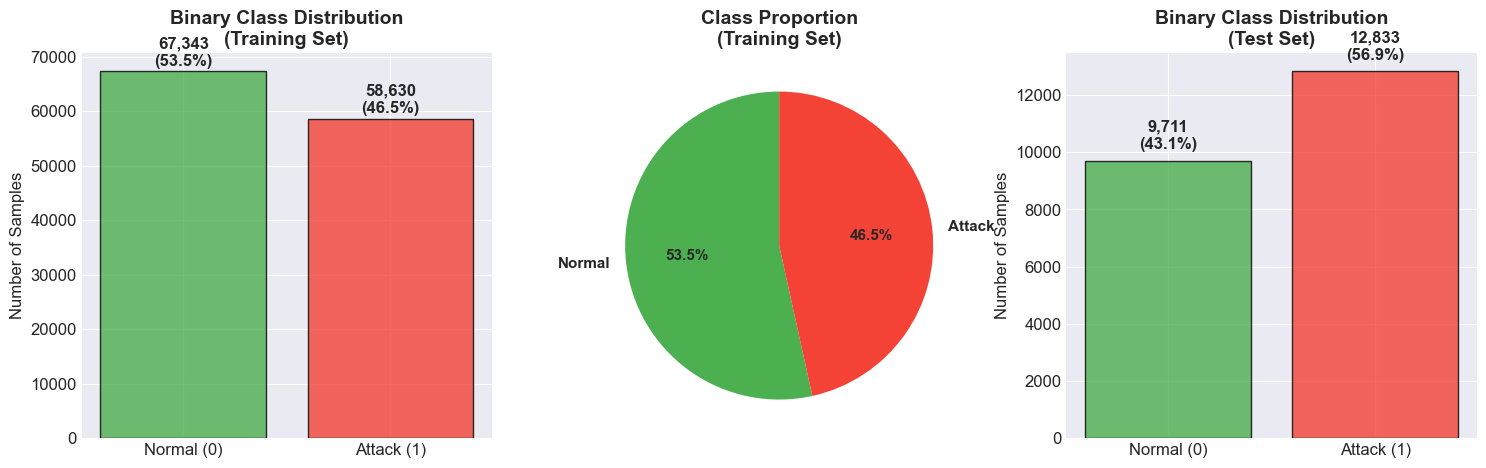

✅ Matplotlib chart saved: figures\Binary_Class_Distribution_(Training_Set)_000.png (Size: 18.0x5.0 in, DPI: 300)
✅ Saved 1 figure(s) to figures


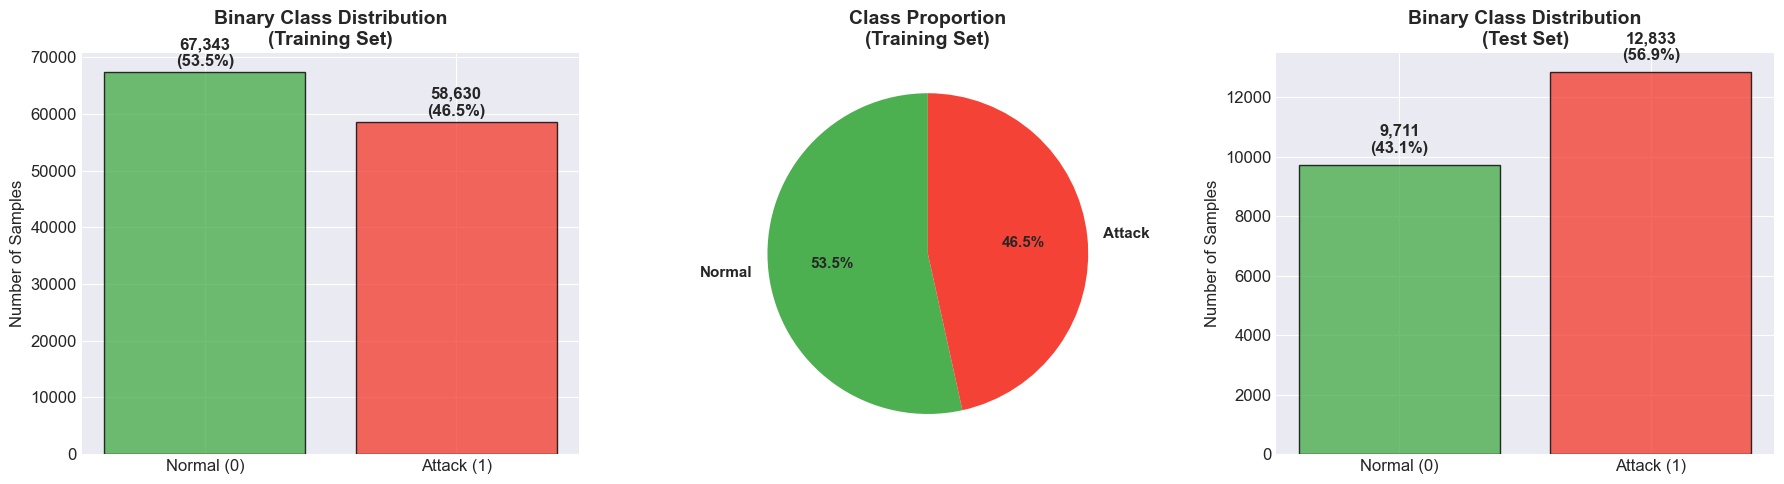

In [27]:
# ================================
# 3. TARGET DISTRIBUTION VISUALIZATION
# ================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ================================
# Training set distribution
# ================================
ax1 = axes[0]

counts = train_df['is_attack_binary'].value_counts().sort_index()

bars = ax1.bar(
    ['Normal (0)', 'Attack (1)'],
    counts.values,
    color=['#4CAF50', '#F44336'],
    edgecolor='black',
    alpha=0.8
)

ax1.set_title('Binary Class Distribution\n(Training Set)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Samples')

for bar, count in zip(bars, counts.values):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 500,
        f'{count:,}\n({count / len(train_df) * 100:.1f}%)',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# ================================
# Pie chart (training set)
# ================================
ax2 = axes[1]

ax2.pie(
    counts.values,
    labels=['Normal', 'Attack'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

ax2.set_title('Class Proportion\n(Training Set)', fontsize=14, fontweight='bold')

# ================================
# Test set distribution
# ================================
ax3 = axes[2]

test_counts = test_df['is_attack_binary'].value_counts().sort_index()

bars = ax3.bar(
    ['Normal (0)', 'Attack (1)'],
    test_counts.values,
    color=['#4CAF50', '#F44336'],
    edgecolor='black',
    alpha=0.8
)

ax3.set_title('Binary Class Distribution\n(Test Set)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Number of Samples')

for bar, count in zip(bars, test_counts.values):
    height = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        height + 300,
        f'{count:,}\n({count / len(test_df) * 100:.1f}%)',
        ha='center',
        va='bottom',
        fontweight='bold'
    )
save_chart(output_folder="../eda/figures")
plt.tight_layout()
save_all_figures_in_session(show=False)
plt.show()


## 4. PROTOCOL ANALYSIS FOR BINARY CLASSIFICATION

✅ Matplotlib chart saved: figures\Protocol_Distribution_by_Class.png (Size: 16.0x6.0 in, DPI: 300)


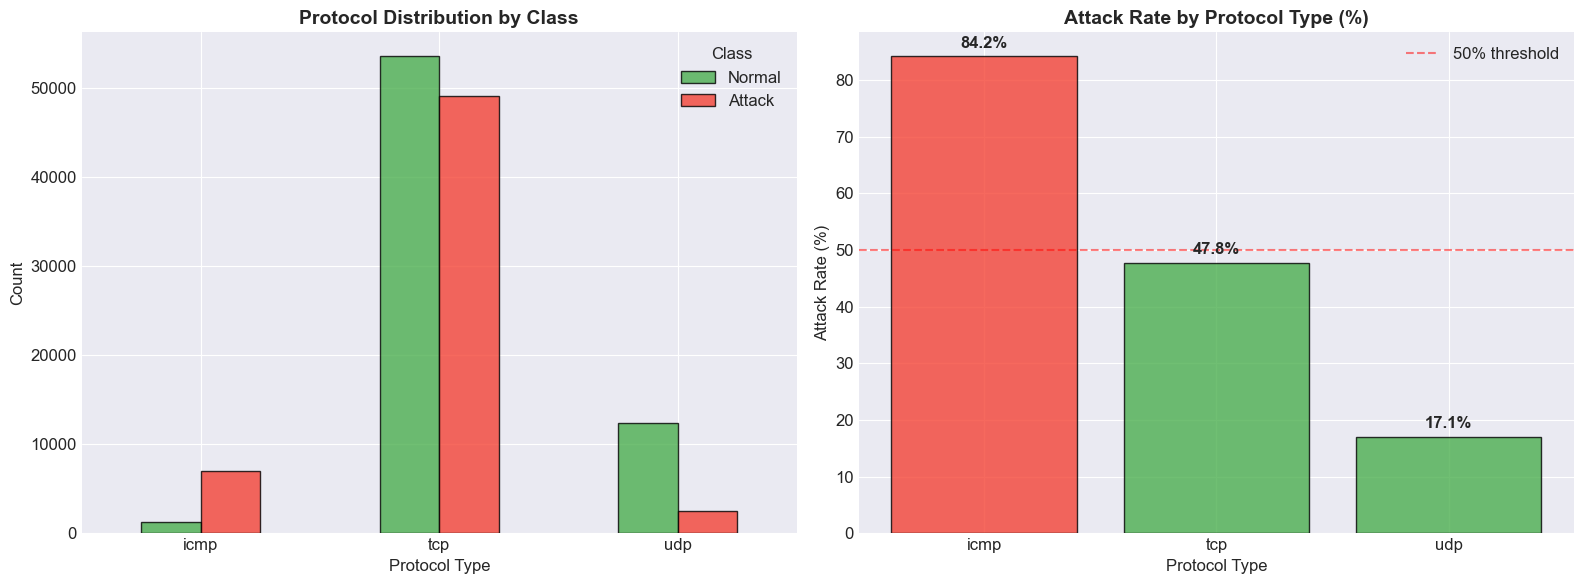

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Protocol distribution by class
protocol_counts = pd.crosstab(train_df['protocol_type'], train_df['is_attack_binary'])
protocol_counts.columns = ['Normal', 'Attack']
protocol_counts.plot(kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'], 
                     edgecolor='black', alpha=0.8)
axes[0].set_title('Protocol Distribution by Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Protocol Type')
axes[0].set_ylabel('Count')
axes[0].legend(title='Class')
axes[0].tick_params(axis='x', rotation=0)

# Attack rate by protocol
attack_rate_by_protocol = train_df.groupby('protocol_type')['is_attack_binary'].mean() * 100
sorted_protocols = attack_rate_by_protocol.sort_values(ascending=False)
bars = axes[1].bar(sorted_protocols.index, sorted_protocols.values, 
                   color=['#F44336' if x > 50 else '#4CAF50' for x in sorted_protocols.values],
                   edgecolor='black', alpha=0.8)
axes[1].set_title('Attack Rate by Protocol Type (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Protocol Type')
axes[1].set_ylabel('Attack Rate (%)')
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
axes[1].legend()

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 1, 
                 f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
save_chart(show=False)
plt.tight_layout()
plt.show()

### Print protocol statistics

In [29]:
for protocol in train_df['protocol_type'].unique():
    normal_count = len(train_df[(train_df['protocol_type'] == protocol) & (train_df['is_attack_binary'] == 0)])
    attack_count = len(train_df[(train_df['protocol_type'] == protocol) & (train_df['is_attack_binary'] == 1)])
    total = normal_count + attack_count
    attack_rate = (attack_count / total * 100) if total > 0 else 0
    print(f"  {protocol:6s}: {total:6,} total | {normal_count:6,} normal | {attack_count:6,} attack | {attack_rate:6.1f}% attack rate")

  tcp   : 102,689 total | 53,600 normal | 49,089 attack |   47.8% attack rate
  udp   : 14,993 total | 12,434 normal |  2,559 attack |   17.1% attack rate
  icmp  :  8,291 total |  1,309 normal |  6,982 attack |   84.2% attack rate


## 5. TOP 10 SERVICES ANALYSIS

✅ Matplotlib chart saved: figures\Top_10_Most_Frequent_Services.png (Size: 18.0x12.0 in, DPI: 300)


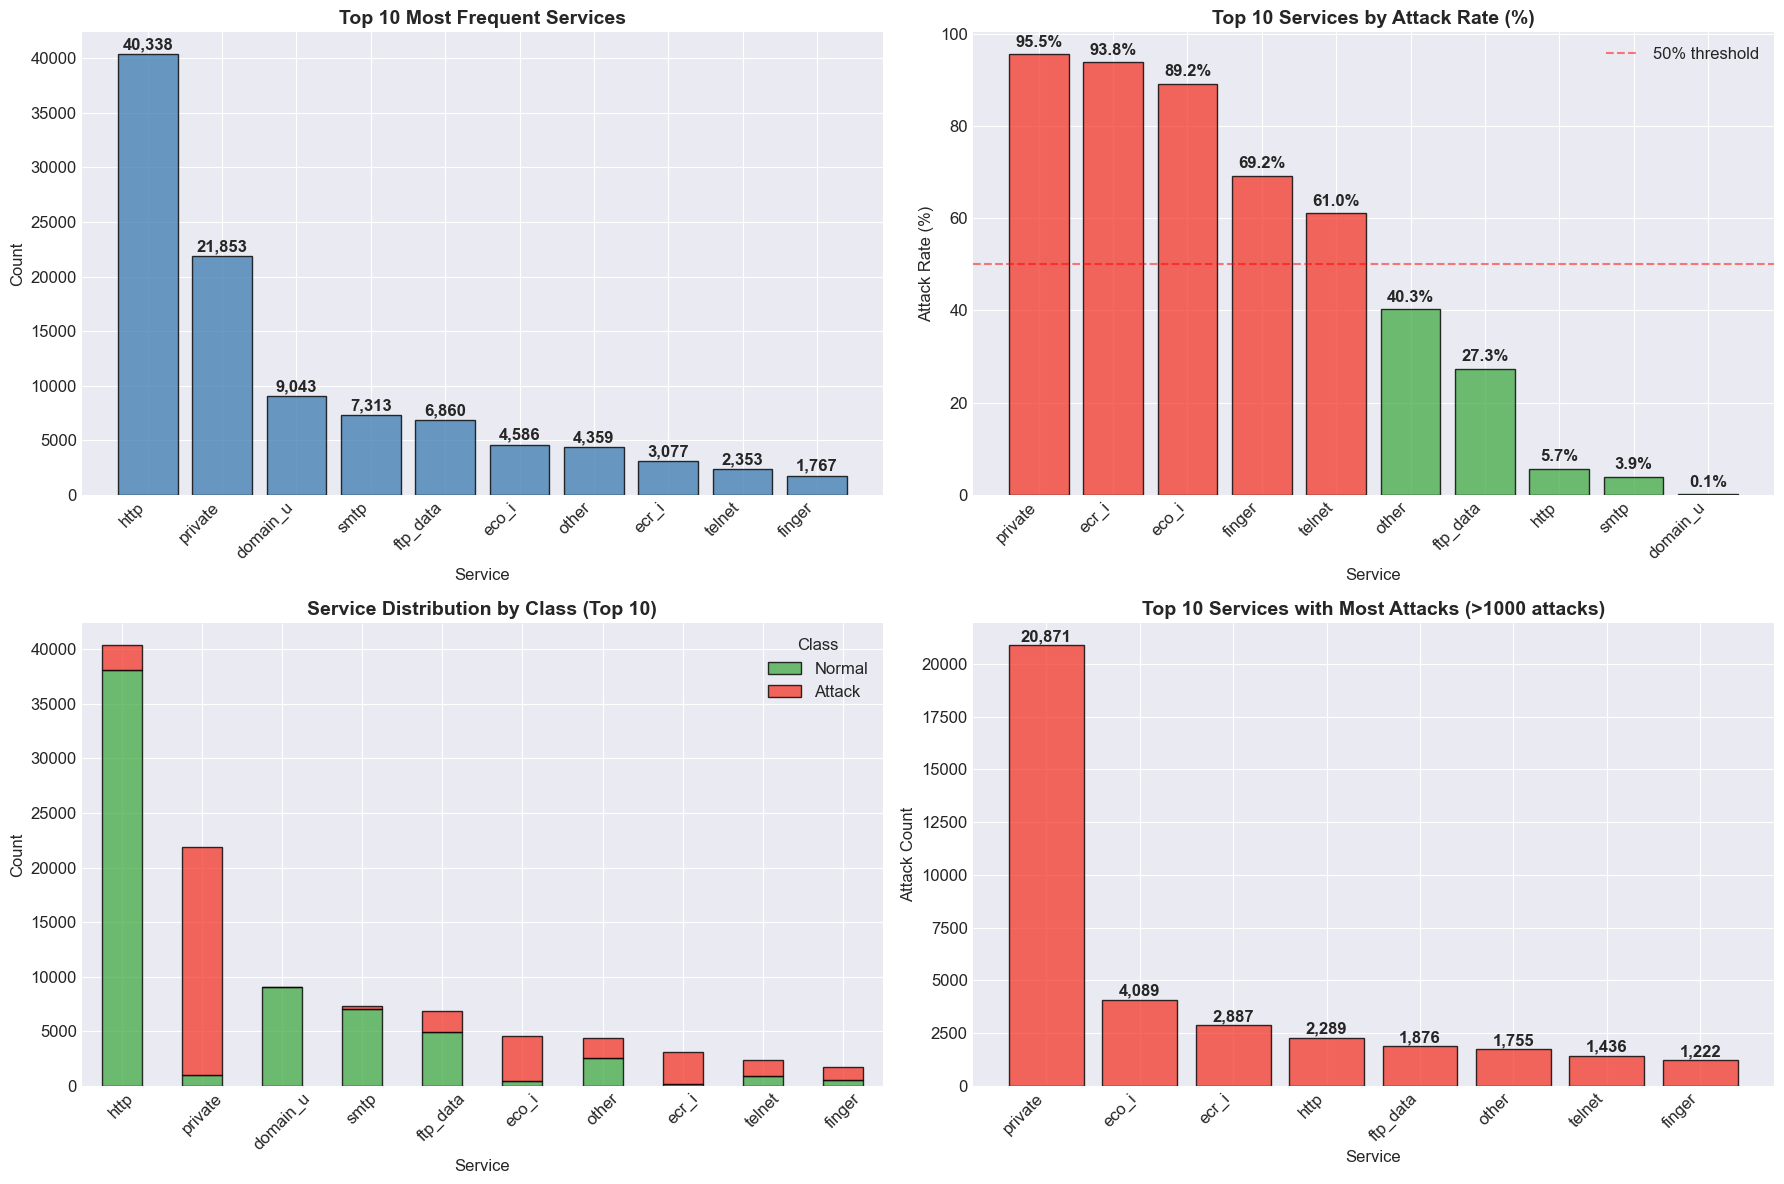

In [30]:
# Get top 10 services
top_services = train_df['service'].value_counts().head(10).index
service_data = train_df[train_df['service'].isin(top_services)]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Top services overall
ax1 = axes[0, 0]
service_counts = train_df['service'].value_counts().head(10)
bars = ax1.bar(range(len(service_counts)), service_counts.values, 
               color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_title('Top 10 Most Frequent Services', fontsize=14, fontweight='bold')
ax1.set_xlabel('Service')
ax1.set_ylabel('Count')
ax1.set_xticks(range(len(service_counts)))
ax1.set_xticklabels(service_counts.index, rotation=45, ha='right')
for i, (bar, count) in enumerate(zip(bars, service_counts.values)):
    ax1.text(i, bar.get_height() + 200, f'{count:,}', ha='center', va='bottom', fontweight='bold')

# 2. Attack rate by service
ax2 = axes[0, 1]
service_attack_rates = []
for service in top_services:
    service_df = train_df[train_df['service'] == service]
    attack_rate = service_df['is_attack_binary'].mean() * 100
    service_attack_rates.append((service, attack_rate))

service_attack_rates.sort(key=lambda x: x[1], reverse=True)
services_sorted = [x[0] for x in service_attack_rates]
rates_sorted = [x[1] for x in service_attack_rates]

colors = ['#F44336' if rate > 50 else '#4CAF50' for rate in rates_sorted]
bars = ax2.bar(range(len(rates_sorted)), rates_sorted, color=colors, edgecolor='black', alpha=0.8)
ax2.set_title('Top 10 Services by Attack Rate (%)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Service')
ax2.set_ylabel('Attack Rate (%)')
ax2.set_xticks(range(len(services_sorted)))
ax2.set_xticklabels(services_sorted, rotation=45, ha='right')
ax2.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax2.legend()

for i, (bar, rate) in enumerate(zip(bars, rates_sorted)):
    ax2.text(i, bar.get_height() + 1, f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

# 3. Service distribution by class (stacked bar)
ax3 = axes[1, 0]
service_class_counts = pd.crosstab(service_data['service'], service_data['is_attack_binary'])
service_class_counts = service_class_counts.reindex(top_services)
service_class_counts.columns = ['Normal', 'Attack']
service_class_counts.plot(kind='bar', stacked=True, ax=ax3, 
                         color=['#4CAF50', '#F44336'], edgecolor='black', alpha=0.8)
ax3.set_title('Service Distribution by Class (Top 10)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Service')
ax3.set_ylabel('Count')
ax3.legend(title='Class')
ax3.tick_params(axis='x', rotation=45)

# 4. Most dangerous services (attack count > 1000)
ax4 = axes[1, 1]
service_attack_counts = train_df[train_df['is_attack_binary'] == 1]['service'].value_counts()
dangerous_services = service_attack_counts[service_attack_counts > 1000].head(10)
bars = ax4.bar(range(len(dangerous_services)), dangerous_services.values, 
               color='#F44336', edgecolor='black', alpha=0.8)
ax4.set_title('Top 10 Services with Most Attacks (>1000 attacks)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Service')
ax4.set_ylabel('Attack Count')
ax4.set_xticks(range(len(dangerous_services)))
ax4.set_xticklabels(dangerous_services.index, rotation=45, ha='right')
for i, (bar, count) in enumerate(zip(bars, dangerous_services.values)):
    ax4.text(i, bar.get_height() + 50, f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
save_chart(show=False)
plt.show()

## 6. NUMERICAL FEATURES - KEY METRICS DISTRIBUTION

✅ Matplotlib chart saved: figures\Key_Numerical_Features_Distribution_Normal_vs_Attack_(Binary_Classification).png (Size: 20.0x16.0 in, DPI: 300)


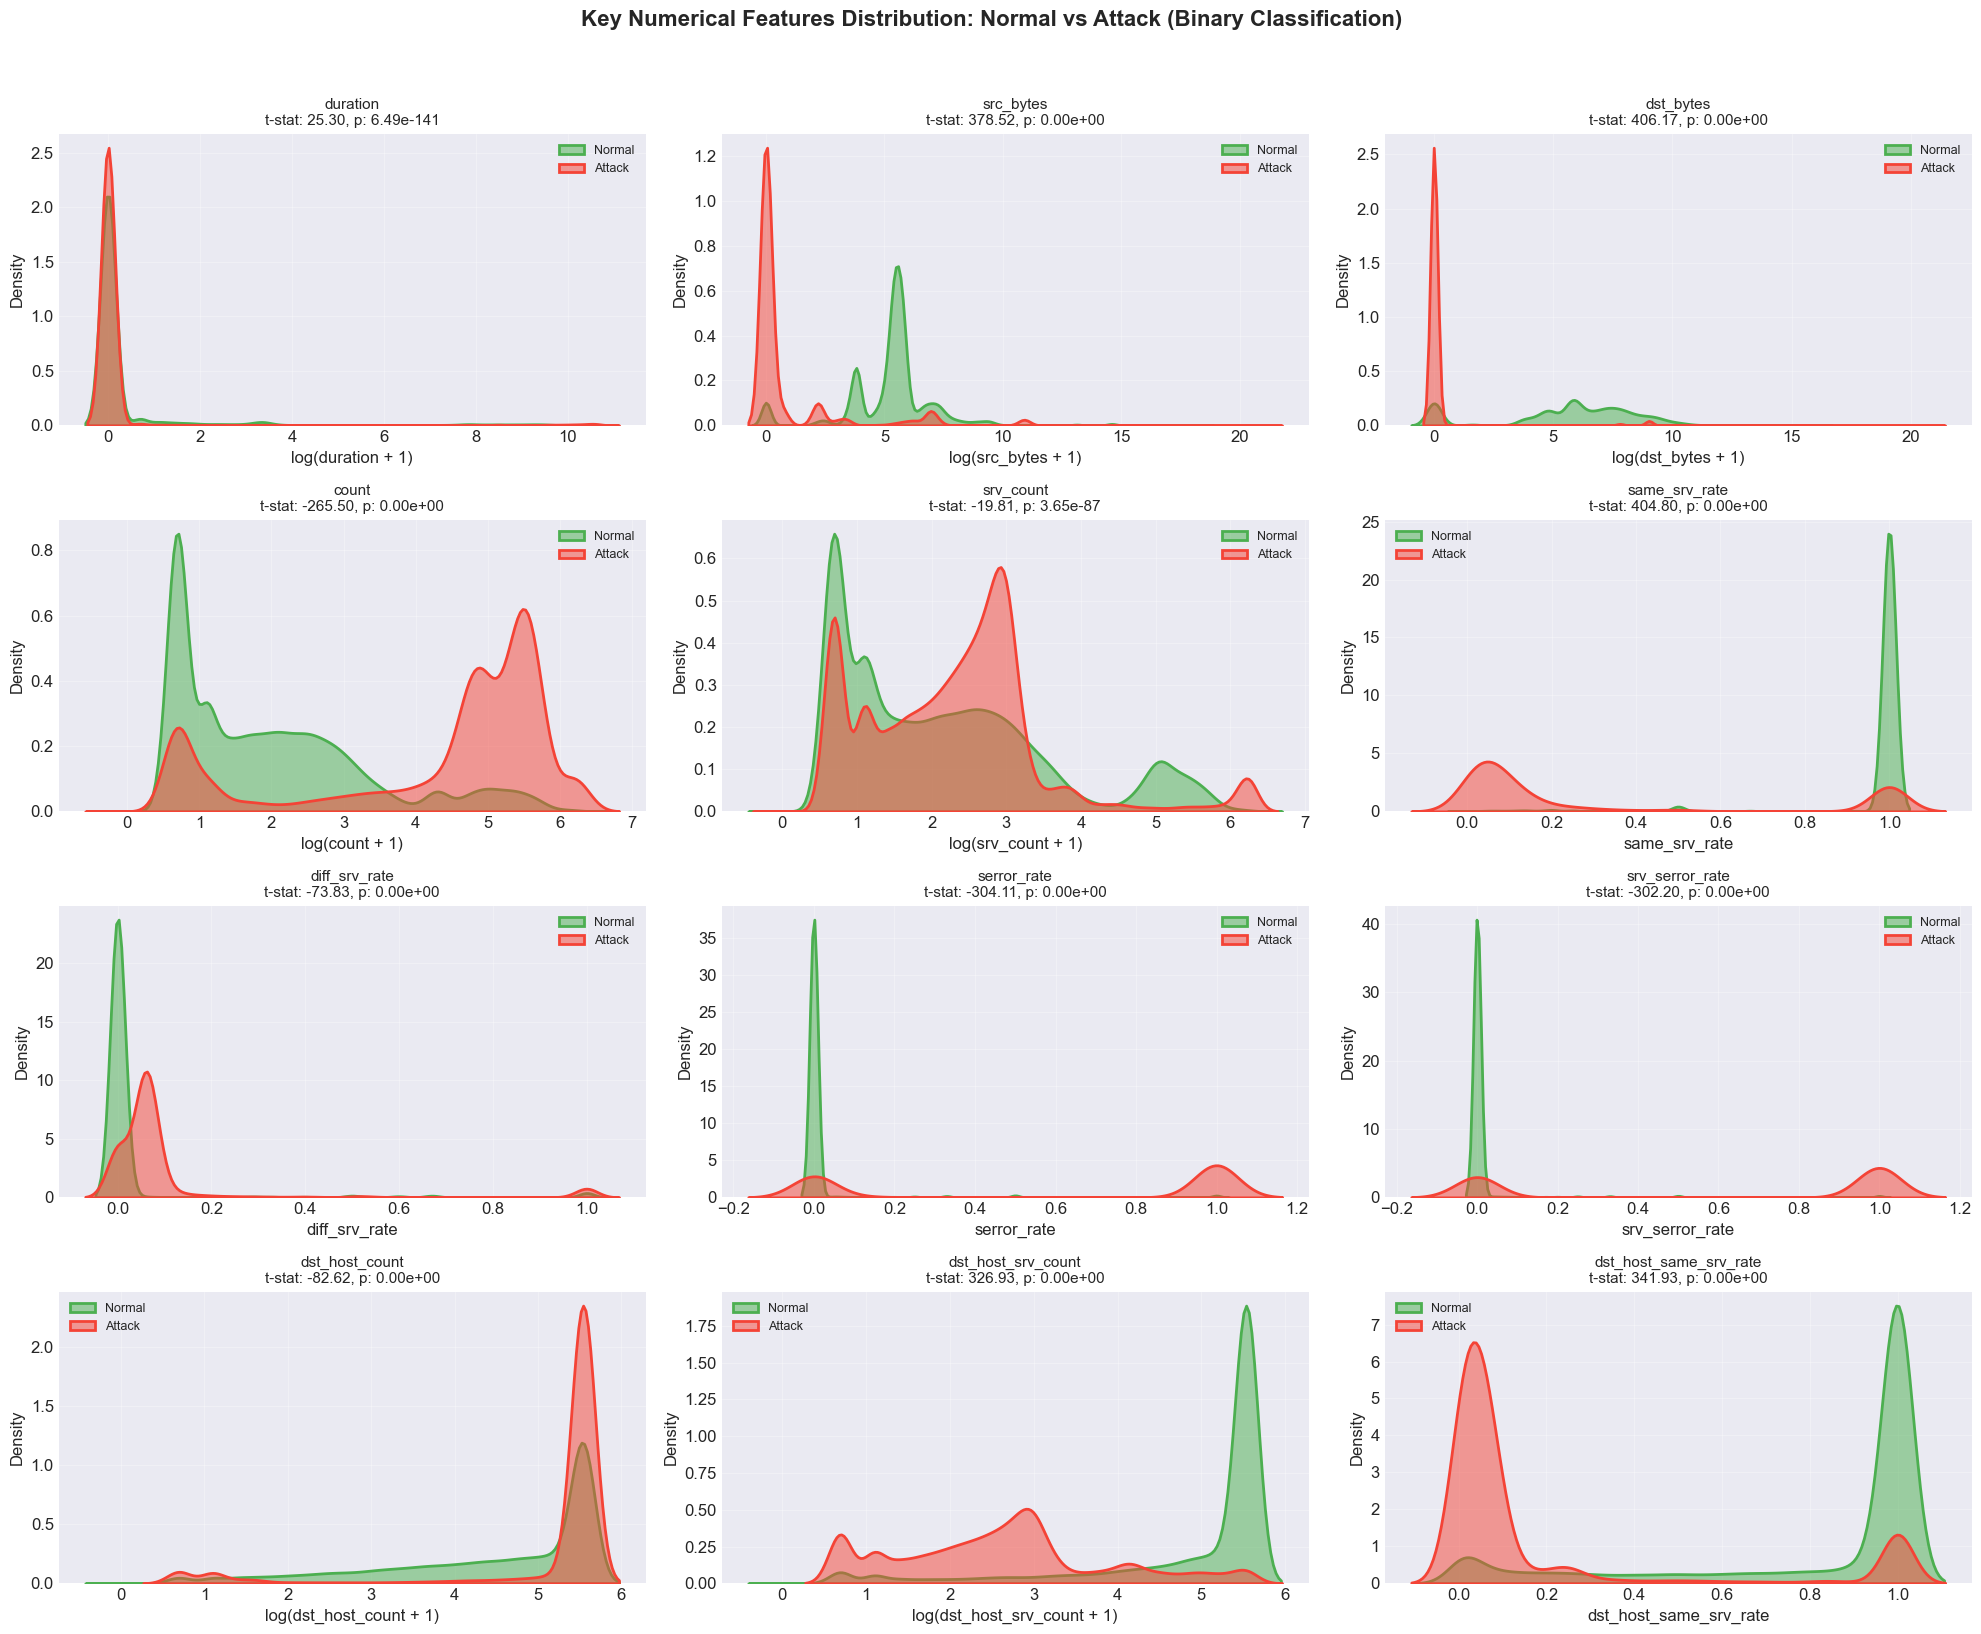

In [31]:
from scipy import stats
# Select key numerical features for binary classification
key_features = [
    'duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count',
    'same_srv_rate', 'diff_srv_rate', 'serror_rate', 'srv_serror_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate'
]

# Filter features that exist in the dataset
key_features = [f for f in key_features if f in train_df.columns]

fig, axes = plt.subplots(4, 3, figsize=(20, 16))
axes = axes.ravel()

for idx, feature in enumerate(key_features[:12]):  # Plot first 12 features
    ax = axes[idx]
    
    # Separate normal and attack distributions
    normal_data = train_df[train_df['is_attack_binary'] == 0][feature]
    attack_data = train_df[train_df['is_attack_binary'] == 1][feature]
    
    # Apply log transform for visualization if needed
    if feature in ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'dst_host_count', 'dst_host_srv_count']:
        normal_data = np.log1p(normal_data)
        attack_data = np.log1p(attack_data)
        xlabel = f'log({feature} + 1)'
    else:
        xlabel = feature
    
    # Plot KDE
    sns.kdeplot(normal_data, ax=ax, label='Normal', color='#4CAF50', fill=True, alpha=0.5, linewidth=2)
    sns.kdeplot(attack_data, ax=ax, label='Attack', color='#F44336', fill=True, alpha=0.5, linewidth=2)
    
    # Calculate and display statistics
    normal_mean = normal_data.mean()
    attack_mean = attack_data.mean()
    t_stat, p_value = stats.ttest_ind(normal_data, attack_data, nan_policy='omit')
    
    ax.set_title(f'{feature}\nt-stat: {t_stat:.2f}, p: {p_value:.2e}', fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(key_features[:12]), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Key Numerical Features Distribution: Normal vs Attack (Binary Classification)', 
             fontsize=16, fontweight='bold', y=1.02)
save_chart(show=False)
plt.tight_layout()
plt.show()

## 7. CORRELATION ANALYSIS WITH BINARY TARGET


Top 20 Features Correlated with Attack (Absolute Value):
----------------------------------------------------------------------
Feature                        Correlation  Direction 
----------------------------------------------------------------------
is_attack_binary                    1.0000 Positive  
same_srv_rate                      -0.7519 Negative  
dst_host_srv_count                 -0.7225 Negative  
dst_host_same_srv_rate             -0.6938 Negative  
logged_in                          -0.6902 Negative  
dst_host_srv_serror_rate            0.6550 Positive  
dst_host_serror_rate                0.6518 Positive  
serror_rate                         0.6507 Positive  
srv_serror_rate                     0.6483 Positive  
count                               0.5764 Positive  
dst_host_count                      0.3751 Positive  
srv_rerror_rate                     0.2535 Positive  
dst_host_srv_rerror_rate            0.2534 Positive  
rerror_rate                         0.2534 

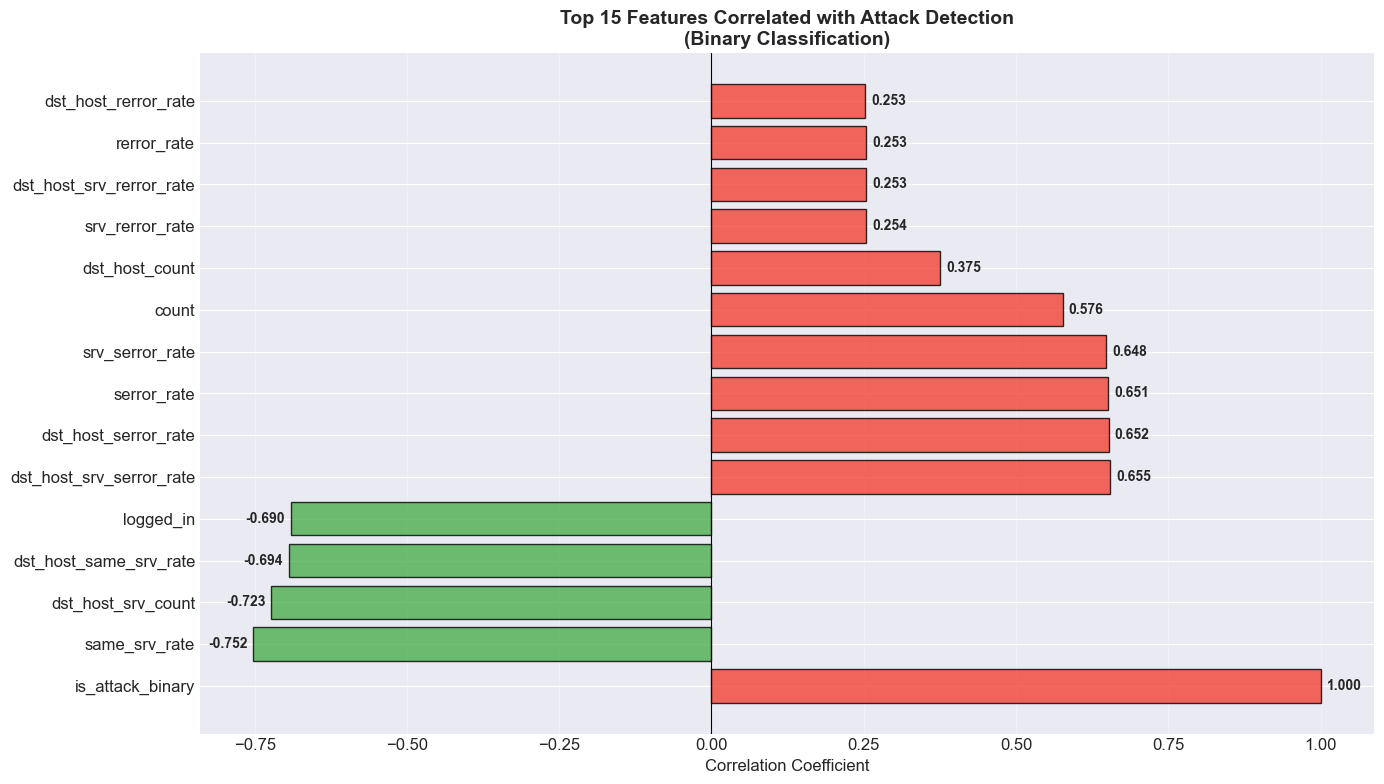

In [32]:

# Calculate correlation with binary target
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
if 'difficulty_level' in numeric_cols:
    numeric_cols.remove('difficulty_level')

correlations = []
for col in numeric_cols:
    if col != 'is_attack':
        corr = train_df[[col, 'is_attack_binary']].corr().iloc[0, 1]
        if not np.isnan(corr):
            correlations.append((col, abs(corr), corr))

# Sort by absolute correlation
correlations.sort(key=lambda x: x[1], reverse=True)

# Display top 20 correlations
print("\nTop 20 Features Correlated with Attack (Absolute Value):")
print("-" * 70)
print(f"{'Feature':<30} {'Correlation':<12} {'Direction':<10}")
print("-" * 70)
for feature, abs_corr, corr in correlations[:20]:
    direction = "Positive" if corr > 0 else "Negative"
    color_code = '\033[91m' if abs_corr > 0.5 else '\033[93m' if abs_corr > 0.3 else '\033[92m'
    print(f"{color_code}{feature:<30} {corr:11.4f} {direction:<10}\033[0m")

# Plot top correlations
top_n = 15
top_features = [x[0] for x in correlations[:top_n]]
top_corr_values = [x[2] for x in correlations[:top_n]]

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#F44336' if val >= 0 else '#4CAF50' for val in top_corr_values]
bars = ax.barh(range(top_n), top_corr_values, color=colors, edgecolor='black', alpha=0.8)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features)
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_title(f'Top {top_n} Features Correlated with Attack Detection\n(Binary Classification)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(x=0, color='black', linewidth=0.8)

# Add correlation value labels
for i, (bar, val) in enumerate(zip(bars, top_corr_values)):
    width = bar.get_width()
    ax.text(width + (0.01 if width >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', ha='left' if width >= 0 else 'right', va='center',
            fontweight='bold', fontsize=10)
save_chart(show=False)
plt.tight_layout()
plt.show()

## 8. BINARY INDICATORS ANALYSIS (FIXED & ROBUST)

✅ Matplotlib chart saved: figures\Binary_Indicator_Features_Attack_Rate_by_Feature_Value_(A_=_Attack_%,_N_=_Normal_%).png (Size: 18.0x10.0 in, DPI: 300)


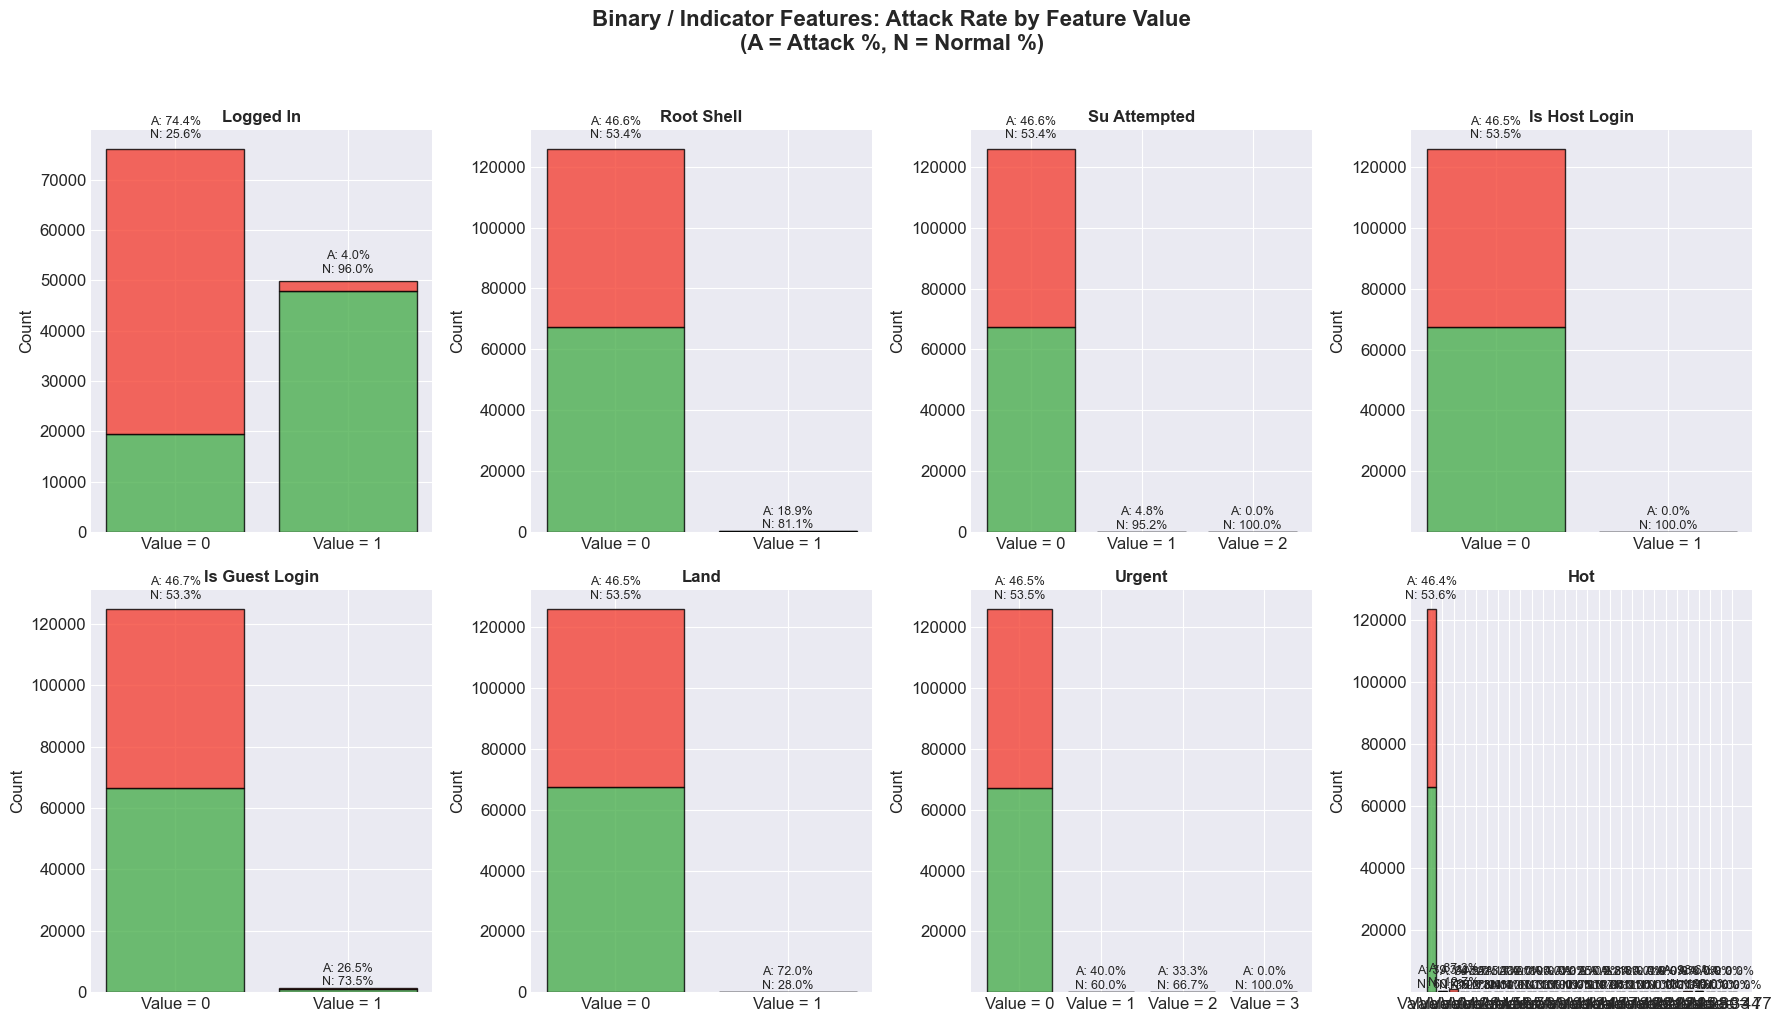

In [33]:
# Define binary / indicator-like features
binary_features = [
    'logged_in', 'root_shell', 'su_attempted', 'is_host_login',
    'is_guest_login', 'land', 'urgent', 'hot'
]

# Keep only features that actually exist
binary_features = [f for f in binary_features if f in train_df.columns]

# Create subplot grid
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(binary_features[:8]):
    ax = axes[idx]

    # Contingency table
    contingency = pd.crosstab(
        train_df[feature],
        train_df['is_attack_binary']
    )

    # Make index labels readable (DO NOT assume binary)
    contingency.index = [
        f'Value = {int(v)}' if pd.notna(v) else 'NaN'
        for v in contingency.index
    ]

    # Percentages per feature value
    percentages = contingency.div(contingency.sum(axis=1), axis=0) * 100

    # Plot stacked bars
    bottom = np.zeros(len(contingency))
    colors = {0: '#4CAF50', 1: '#F44336'}

    for cls in contingency.columns:
        ax.bar(
            range(len(contingency)),
            contingency[cls],
            bottom=bottom,
            color=colors[int(cls)],
            edgecolor='black',
            alpha=0.8,
            label='Normal' if cls == 0 else 'Attack'
        )
        bottom += contingency[cls].values

    # Axis formatting
    ax.set_title(feature.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xticks(range(len(contingency)))
    ax.set_xticklabels(contingency.index)

    # Add percentage annotations
    for i, (_, row) in enumerate(percentages.iterrows()):
        ax.text(
            i,
            contingency.iloc[i].sum() * 1.02,
            f"A: {row.get(1, 0):.1f}%\nN: {row.get(0, 0):.1f}%",
            ha='center',
            va='bottom',
            fontsize=9
        )

# Hide unused subplots
for i in range(len(binary_features[:8]), len(axes)):
    axes[i].axis('off')

# Global title
plt.suptitle(
    'Binary / Indicator Features: Attack Rate by Feature Value\n(A = Attack %, N = Normal %)',
    fontsize=16,
    fontweight='bold',
    y=1.02
)
save_chart(show=False)
plt.tight_layout()
plt.show()


✅ Matplotlib chart saved: figures\Login_&_Land_Indicators_Attack_Rate_by_Feature_Value_(A_=_Attack_%,_N_=_Normal_%).png (Size: 12.0x6.0 in, DPI: 300)


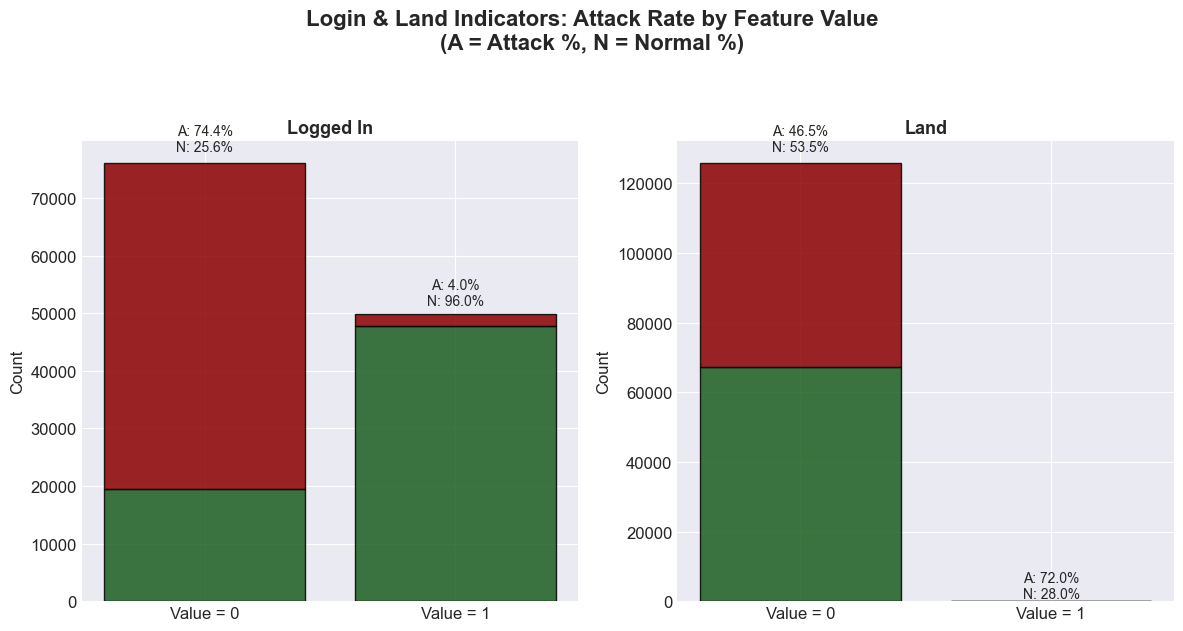

In [39]:
# Define only the desired binary features
binary_features = ['logged_in', 'land']
binary_features = [f for f in binary_features if f in train_df.columns]

# Create subplot grid (1 row, 2 columns)
fig, axes = plt.subplots(1, len(binary_features), figsize=(12, 6))
axes = np.atleast_1d(axes)

for idx, feature in enumerate(binary_features):
    ax = axes[idx]

    # Contingency table
    contingency = pd.crosstab(
        train_df[feature],
        train_df['is_attack_binary']
    )

    # Readable index labels
    contingency.index = [
        f'Value = {int(v)}' if pd.notna(v) else 'NaN'
        for v in contingency.index
    ]

    # Percentages per feature value
    percentages = contingency.div(contingency.sum(axis=1), axis=0) * 100

    # Plot stacked bars
    bottom = np.zeros(len(contingency))
    colors = {
        0: '#1B5E20',  # dark green (Normal)
        1: '#8B0000'   # dark red (Attack)
    }

    for cls in contingency.columns:
        ax.bar(
            range(len(contingency)),
            contingency[cls],
            bottom=bottom,
            color=colors[int(cls)],
            edgecolor='black',
            alpha=0.85,
            label='Normal' if cls == 0 else 'Attack'
        )
        bottom += contingency[cls].values

    # Axis formatting
    ax.set_title(feature.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xticks(range(len(contingency)))
    ax.set_xticklabels(contingency.index)

    # Percentage annotations
    for i, (_, row) in enumerate(percentages.iterrows()):
        ax.text(
            i,
            contingency.iloc[i].sum() * 1.02,
            f"A: {row.get(1, 0):.1f}%\nN: {row.get(0, 0):.1f}%",
            ha='center',
            va='bottom',
            fontsize=10
        )

# Global title
plt.suptitle(
    'Login & Land Indicators: Attack Rate by Feature Value\n(A = Attack %, N = Normal %)',
    fontsize=16,
    fontweight='bold',
    y=1.05
)

save_chart(show=False)
plt.tight_layout()
plt.show()


## 9. FEATURE IMPORTANCE SUMMARY FOR BINARY CLASSIFICATION

In [34]:

print("🔴 HIGH IMPORTANCE FEATURES (|corr| > 0.5):")
for feature, abs_corr, corr in correlations:
    if abs_corr > 0.5:
        direction = "INCREASES attack probability" if corr > 0 else "DECREASES attack probability"
        print(f"  • {feature:25} | corr: {corr:7.3f} | {direction}")

print("🟡 MEDIUM IMPORTANCE FEATURES (0.3 < |corr| ≤ 0.5):")
for feature, abs_corr, corr in correlations:
    if 0.3 < abs_corr <= 0.5:
        direction = "increases attack probability" if corr > 0 else "decreases attack probability"
        print(f"  • {feature:25} | corr: {corr:7.3f} | {direction}")

print("🟢 BINARY FEATURES WITH HIGH ATTACK ASSOCIATION:")
for feature in binary_features:
    if feature in train_df.columns:
        attack_rate_when_true = train_df[train_df[feature] == 1]['is_attack_binary'].mean() * 100
        if attack_rate_when_true > 70:  # High threshold
            print(f"  • {feature:25} | Attack rate when True: {attack_rate_when_true:6.1f}%")


🔴 HIGH IMPORTANCE FEATURES (|corr| > 0.5):
  • is_attack_binary          | corr:   1.000 | INCREASES attack probability
  • same_srv_rate             | corr:  -0.752 | DECREASES attack probability
  • dst_host_srv_count        | corr:  -0.723 | DECREASES attack probability
  • dst_host_same_srv_rate    | corr:  -0.694 | DECREASES attack probability
  • logged_in                 | corr:  -0.690 | DECREASES attack probability
  • dst_host_srv_serror_rate  | corr:   0.655 | INCREASES attack probability
  • dst_host_serror_rate      | corr:   0.652 | INCREASES attack probability
  • serror_rate               | corr:   0.651 | INCREASES attack probability
  • srv_serror_rate           | corr:   0.648 | INCREASES attack probability
  • count                     | corr:   0.576 | INCREASES attack probability
🟡 MEDIUM IMPORTANCE FEATURES (0.3 < |corr| ≤ 0.5):
  • dst_host_count            | corr:   0.375 | increases attack probability
🟢 BINARY FEATURES WITH HIGH ATTACK ASSOCIATION:
  • land   

In [35]:
train_df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level',
       'is_attack_multiclass', 'is_attack_binary'],
      dtype='object')

In [36]:
train_df.shape

(125973, 45)

In [37]:
train_df.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level,is_attack_multiclass,is_attack_binary
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,normal,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,normal,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,dos,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,normal,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,normal,0


In [38]:
DATA_FEATURES_PATH = "../data/processed/"
train_df.to_parquet(f"{DATA_FEATURES_PATH}nsl_kdd_processed.parquet", index=False)